# Extraccion inicial

In [6]:
import pandas as pd
import numpy as np
import re

In [7]:
carpeta = 'Datos entrada'
nombre = 'X_ml_ready.parquet'
ruta = carpeta + '/' + nombre
df = pd.read_parquet(ruta)
df.head()

,SCORE_BASE,FACILIDAD,REFERENCE_COUNT,CPE_COUNT,DAYS_SINCE_PUBLISHED,DAYS_SINCE_MODIFIED,EPSS_SCORE,EPSS_PERCENTILE,VENDOR_OTHER_VENDOR,VENDOR_adobe,...,IMP_INTEGR_NONE,IMP_INTEGR_PARTIAL,IMP_DISPON_COMPLETE,IMP_DISPON_HIGH,IMP_DISPON_LOW,IMP_DISPON_NONE,IMP_DISPON_PARTIAL,CVSS_VERSION_2.0,CVSS_VERSION_3.0,CVSS_VERSION_3.1
0,10.0,10.0,10,1,13742,32,0.21681,0.95778,1,0,...,False,False,True,False,False,False,False,True,False,False
1,10.0,10.0,2,2,13701,32,0.02894,0.86417,1,0,...,False,False,True,False,False,False,False,True,False,False
2,7.2,3.9,6,2,13650,32,0.00929,0.76225,1,0,...,False,False,True,False,False,False,False,True,False,False
3,4.6,3.9,8,3,13444,32,0.00099,0.26826,0,0,...,False,True,False,False,False,False,True,True,False,False
4,10.0,10.0,6,5,13352,32,0.04067,0.88607,0,0,...,False,False,True,False,False,False,False,True,False,False


In [8]:
carpeta = 'Datos entrada'
nombre_1 = 'y_kev.csv'
nombre_2 = 'y_risk_score.csv'
nombre_3 = 'y_risk_tier.csv'
ruta_1 = carpeta + '/' + nombre_1
ruta_2 = carpeta + '/' + nombre_2
ruta_3 = carpeta + '/' + nombre_3
df_ykev = pd.read_csv(ruta_1)
df_risks = pd.read_csv(ruta_2)
df_riskt = pd.read_csv(ruta_3)

In [9]:
df_model_pre1 = df.merge(df_ykev,how='inner',left_index=True,right_index=True)
df_model_pre2 = df_model_pre1.merge(df_risks,how='inner',left_index=True,right_index=True)
df_model = df_model_pre2.merge(df_riskt,how='inner',left_index=True,right_index=True)
# df_model.head().to_excel('Muestra datos de entrada.xlsx',index=False)
df_model.drop(['EPSS_SCORE','EPSS_PERCENTILE'],axis=1,inplace=True)
df_model.drop(['DAYS_SINCE_MODIFIED','DAYS_SINCE_PUBLISHED'],axis=1,inplace=True)
df_model.head()

,SCORE_BASE,FACILIDAD,REFERENCE_COUNT,CPE_COUNT,VENDOR_OTHER_VENDOR,VENDOR_adobe,VENDOR_apache,VENDOR_apple,VENDOR_canonical,VENDOR_cisco,...,IMP_DISPON_HIGH,IMP_DISPON_LOW,IMP_DISPON_NONE,IMP_DISPON_PARTIAL,CVSS_VERSION_2.0,CVSS_VERSION_3.0,CVSS_VERSION_3.1,IS_KEV,RISK_SCORE,RISK_TIER
0,10.0,10.0,10,1,1,0,0,0,0,0,...,False,False,False,False,True,False,False,0,0.425883,3
1,10.0,10.0,2,2,1,0,0,0,0,0,...,False,False,False,False,True,False,False,0,0.360129,3
2,7.2,3.9,6,2,1,0,0,0,0,0,...,False,False,False,False,True,False,False,0,0.222251,1
3,4.6,3.9,8,3,0,0,0,0,0,0,...,False,False,False,True,True,False,False,0,0.154346,0
4,10.0,10.0,6,5,0,0,0,0,0,0,...,False,False,False,False,True,False,False,0,0.364235,3


# Modelos

In [5]:
# =========================================================
# LIBRERIAS
# =========================================================

import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    balanced_accuracy_score,
    classification_report
)

# Modelos
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import (
    RandomForestClassifier,
    ExtraTreesClassifier,
    GradientBoostingClassifier
)

# Boosting externos
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

# =========================================================
# DATOS
# =========================================================

# X = dataframe de features
# y = target binario y_kev

# EJEMPLO:
X = df_model.drop(columns=['IS_KEV'])
y = df_model['IS_KEV']

# =========================================================
# TRAIN TEST SPLIT
# =========================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# =========================================================
# PESO PARA DESBALANCE
# =========================================================

neg = (y_train == 0).sum()
pos = (y_train == 1).sum()

scale_pos_weight = neg / pos

print(f"Negativos: {neg}")
print(f"Positivos: {pos}")
print(f"scale_pos_weight: {scale_pos_weight:.2f}")

# =========================================================
# MODELOS
# =========================================================

models = {

    "LogisticRegression": LogisticRegression(
        class_weight='balanced',
        max_iter=2000,
        random_state=42
    ),

    "RandomForest": RandomForestClassifier(
        n_estimators=300,
        max_depth=None,
        class_weight='balanced',
        random_state=42,
        n_jobs=-1
    ),

    "ExtraTrees": ExtraTreesClassifier(
        n_estimators=300,
        class_weight='balanced',
        random_state=42,
        n_jobs=-1
    ),

    "GradientBoosting": GradientBoostingClassifier(
        n_estimators=200,
        learning_rate=0.05,
        random_state=42
    ),

    "XGBoost": XGBClassifier(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        scale_pos_weight=scale_pos_weight,
        eval_metric='logloss',
        random_state=42,
        n_jobs=-1
    ),

    "LightGBM": LGBMClassifier(
        n_estimators=300,
        learning_rate=0.05,
        scale_pos_weight=scale_pos_weight,
        random_state=42,
        n_jobs=-1
    ),

    "CatBoost": CatBoostClassifier(
        iterations=300,
        learning_rate=0.05,
        depth=6,
        auto_class_weights='Balanced',
        verbose=0,
        random_state=42
    )
}

# =========================================================
# ENTRENAMIENTO Y EVALUACION
# =========================================================

results = []

for name, model in models.items():

    print("=" * 60)
    print(f"Entrenando: {name}")

    # Entrenamiento
    model.fit(X_train, y_train)

    # Predicciones
    y_pred = model.predict(X_test)

    # Probabilidades
    y_prob = model.predict_proba(X_test)[:, 1]

    # Métricas
    acc = accuracy_score(y_test, y_pred)

    precision = precision_score(y_test, y_pred, zero_division=0)

    recall = recall_score(y_test, y_pred)

    f1 = f1_score(y_test, y_pred)

    roc_auc = roc_auc_score(y_test, y_prob)

    pr_auc = average_precision_score(y_test, y_prob)

    bal_acc = balanced_accuracy_score(y_test, y_pred)

    # Guardar resultados
    results.append({
        'Model': name,
        'Accuracy': acc,
        'Balanced_Accuracy': bal_acc,
        'Precision': precision,
        'Recall': recall,
        'F1': f1,
        'ROC_AUC': roc_auc,
        'PR_AUC': pr_auc
    })

# =========================================================
# RESULTADOS
# =========================================================

df_results = pd.DataFrame(results)

# Ordenar por PR-AUC
df_results = df_results.sort_values(
    by='PR_AUC',
    ascending=False
)

print("\n")
print("=" * 80)
print("RESUMEN DE MODELOS")
print("=" * 80)

print(df_results)

# =========================================================
# OPCIONAL: EXPORTAR
# =========================================================

# df_results.to_csv(
#     'comparacion_modelos_ykev.csv',
#     index=False
# )

KeyboardInterrupt: 

In [ ]:
df_results

,Model,Accuracy,Balanced_Accuracy,Precision,Recall,F1,ROC_AUC,PR_AUC
5,LightGBM,0.998111,0.959811,0.748718,0.921136,0.826025,0.998135,0.930282
4,XGBoost,0.993702,0.968583,0.432706,0.943218,0.593254,0.998563,0.921258
6,CatBoost,0.991259,0.970495,0.352459,0.949527,0.514091,0.998657,0.913218
1,RandomForest,0.997650,0.769662,0.960674,0.539432,0.690909,0.996932,0.885682
3,GradientBoosting,0.997957,0.829460,0.893162,0.659306,0.758621,0.996290,0.825099
2,ExtraTrees,0.996943,0.708094,0.904110,0.416404,0.570194,0.981380,0.743200
0,LogisticRegression,0.932178,0.950227,0.065153,0.968454,0.122092,0.981626,0.182682


Negativos: 259118
Positivos: 1270
scale_pos_weight: 204.03
Entrenando: RandomForest
Entrenando: ExtraTrees
Entrenando: GradientBoosting
Entrenando: XGBoost
Entrenando: LightGBM
[LightGBM] [Info] Number of positive: 1270, number of negative: 259118
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.045339 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 775
[LightGBM] [Info] Number of data points in the train set: 260388, number of used features: 144
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.004877 -> initscore=-5.318267
[LightGBM] [Info] Start training from score -5.318267
Entrenando: CatBoost


RESULTADOS MODELOS
              Model  Accuracy  Balanced_Accuracy  Precision    Recall  \
4          LightGBM  0.967587           0.900527   0.113744  0.832808   
3           XGBoost  0.959245           0.915171   0.095568  0.870662   
2  

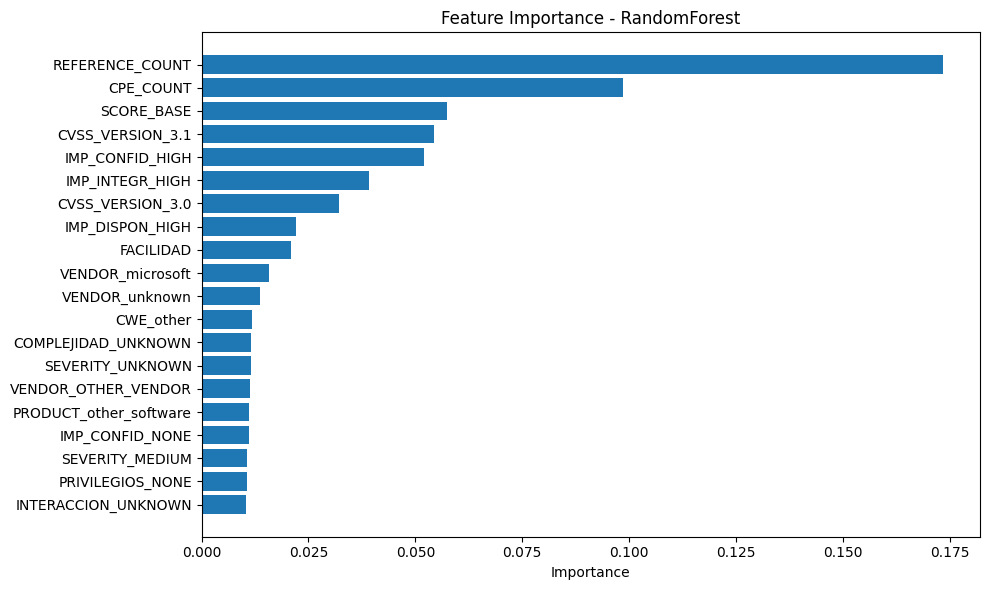



TOP 20 FEATURES - ExtraTrees
                       Feature  Importance
2              REFERENCE_COUNT    0.096902
149           CVSS_VERSION_3.1    0.060280
133            IMP_CONFID_HIGH    0.057371
138            IMP_INTEGR_HIGH    0.053762
3                    CPE_COUNT    0.042187
148           CVSS_VERSION_3.0    0.031685
52              VENDOR_unknown    0.027882
143            IMP_DISPON_HIGH    0.027213
31            VENDOR_microsoft    0.023919
0                   SCORE_BASE    0.019322
112            SEVERITY_MEDIUM    0.017562
70      PRODUCT_other_software    0.015956
93                   CWE_other    0.015558
4          VENDOR_OTHER_VENDOR    0.014788
135            IMP_CONFID_NONE    0.014286
124           PRIVILEGIOS_NONE    0.013596
75   PRODUCT_windows_ecosystem    0.013451
56     PRODUCT_apple_ecosystem    0.013018
128        INTERACCION_UNKNOWN    0.012355
1                    FACILIDAD    0.011415


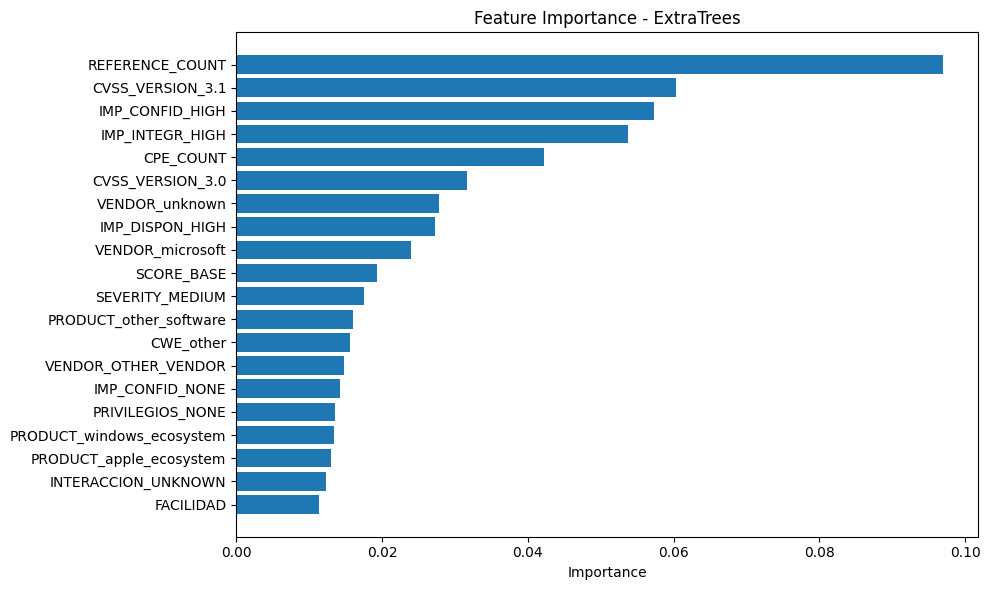



TOP 20 FEATURES - GradientBoosting
                       Feature  Importance
2              REFERENCE_COUNT    0.482008
3                    CPE_COUNT    0.089503
149           CVSS_VERSION_3.1    0.067723
31            VENDOR_microsoft    0.054162
5                 VENDOR_adobe    0.043082
0                   SCORE_BASE    0.025409
109          SEVERITY_CRITICAL    0.020436
69        PRODUCT_office_suite    0.018656
62        PRODUCT_email_server    0.015999
133            IMP_CONFID_HIGH    0.015648
81       CWE_command_injection    0.014613
53               VENDOR_vmware    0.014195
138            IMP_INTEGR_HIGH    0.013364
9                 VENDOR_cisco    0.012699
61   PRODUCT_developer_runtime    0.008511
16             VENDOR_fortinet    0.008380
20               VENDOR_google    0.007682
56     PRODUCT_apple_ecosystem    0.007098
65     PRODUCT_linux_ecosystem    0.004383
38               VENDOR_oracle    0.004372


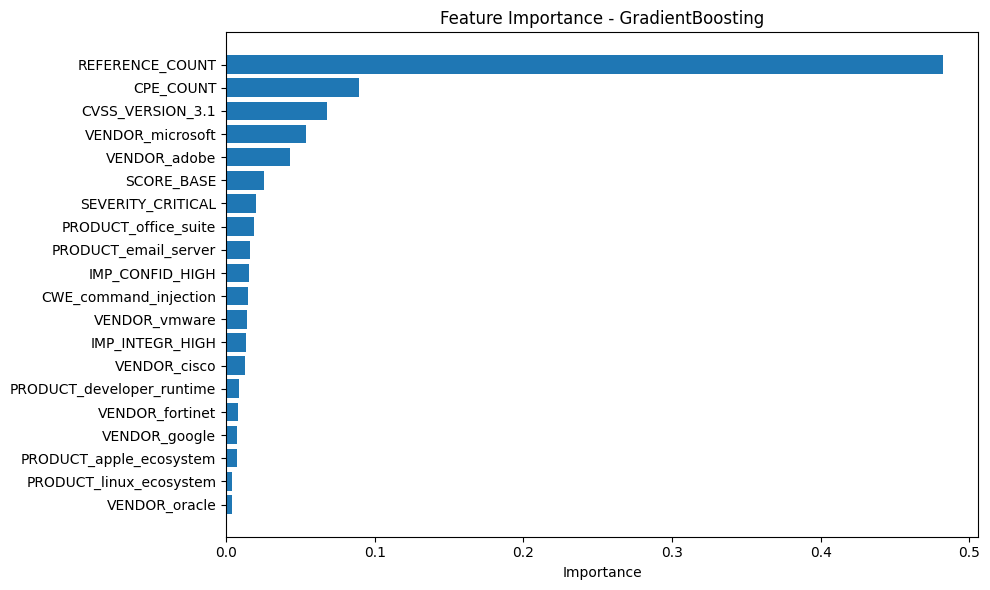



TOP 20 FEATURES - XGBoost
                     Feature  Importance
121      COMPLEJIDAD_UNKNOWN    0.138775
148         CVSS_VERSION_3.0    0.124359
133          IMP_CONFID_HIGH    0.085021
149         CVSS_VERSION_3.1    0.073211
138          IMP_INTEGR_HIGH    0.049591
52            VENDOR_unknown    0.022475
2            REFERENCE_COUNT    0.017145
113         SEVERITY_UNKNOWN    0.016736
9               VENDOR_cisco    0.011917
124         PRIVILEGIOS_NONE    0.011911
31          VENDOR_microsoft    0.011819
28            VENDOR_juniper    0.011440
3                  CPE_COUNT    0.010825
118       VEC_ATAQUE_UNKNOWN    0.008608
16           VENDOR_fortinet    0.007707
67     PRODUCT_mobile_device    0.007589
73    PRODUCT_virtualization    0.007463
65   PRODUCT_linux_ecosystem    0.007381
62      PRODUCT_email_server    0.007116
81     CWE_command_injection    0.007061


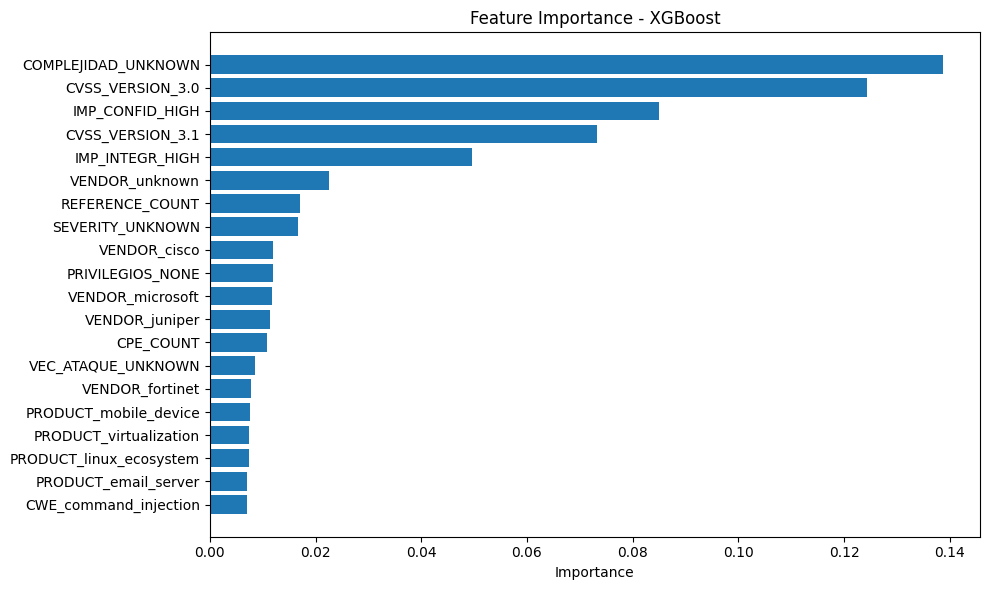



TOP 20 FEATURES - LightGBM
                     Feature  Importance
2            REFERENCE_COUNT        1778
3                  CPE_COUNT        1143
0                 SCORE_BASE         650
1                  FACILIDAD         369
4        VENDOR_OTHER_VENDOR         161
99               CWE_unknown         133
31          VENDOR_microsoft         127
93                 CWE_other         111
91     CWE_memory_corruption          99
70    PRODUCT_other_software          94
140          IMP_INTEGR_NONE          89
81     CWE_command_injection          89
88      CWE_input_validation          85
123          PRIVILEGIOS_LOW          84
9               VENDOR_cisco          80
65   PRODUCT_linux_ecosystem          77
124         PRIVILEGIOS_NONE          77
129          ALCANCE_CHANGED          75
67     PRODUCT_mobile_device          75
94        CWE_path_traversal          73


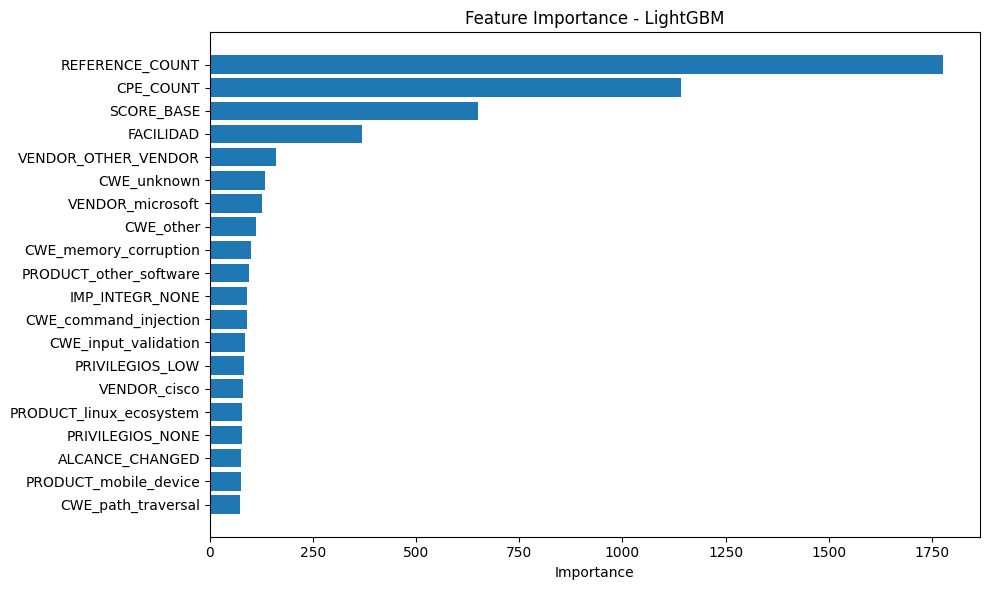



TOP 20 FEATURES - CatBoost
                     Feature  Importance
2            REFERENCE_COUNT   21.533580
149         CVSS_VERSION_3.1   21.146446
3                  CPE_COUNT    5.189460
52            VENDOR_unknown    4.728256
133          IMP_CONFID_HIGH    3.392725
148         CVSS_VERSION_3.0    2.759041
147         CVSS_VERSION_2.0    2.538899
128      INTERACCION_UNKNOWN    1.744023
31          VENDOR_microsoft    1.712927
1                  FACILIDAD    1.665850
138          IMP_INTEGR_HIGH    1.588498
0                 SCORE_BASE    1.524796
124         PRIVILEGIOS_NONE    1.409192
65   PRODUCT_linux_ecosystem    1.209189
113         SEVERITY_UNKNOWN    1.200386
131          ALCANCE_UNKNOWN    1.121185
83    CWE_database_injection    1.083461
121      COMPLEJIDAD_UNKNOWN    1.005469
135          IMP_CONFID_NONE    0.968957
140          IMP_INTEGR_NONE    0.813118


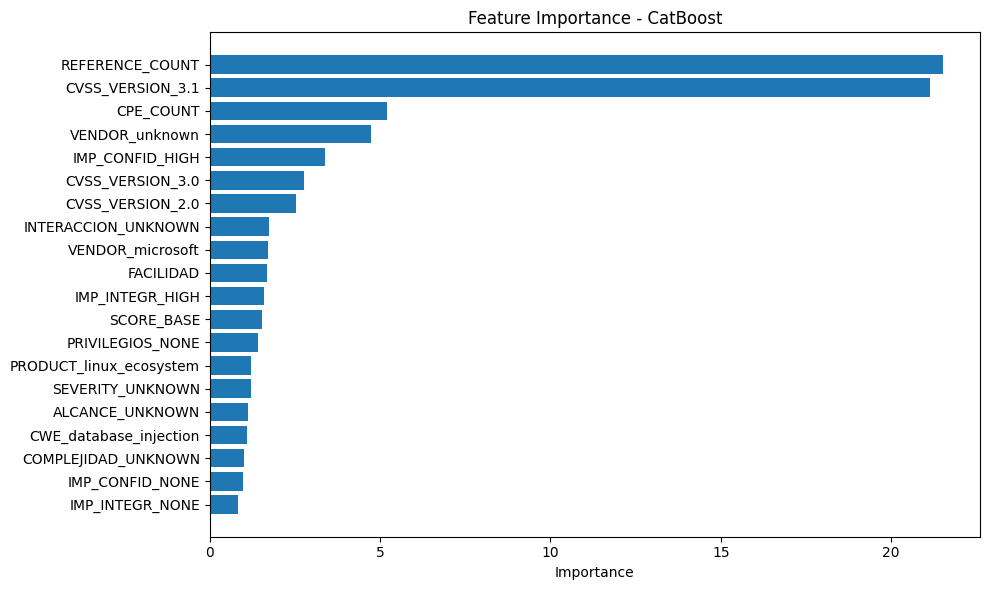

In [ ]:
# =========================================================
# LIBRERIAS
# =========================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    balanced_accuracy_score
)

# =========================================================
# MODELOS
# =========================================================

from sklearn.ensemble import (
    RandomForestClassifier,
    ExtraTreesClassifier,
    GradientBoostingClassifier
)

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

# =========================================================
# DATOS
# =========================================================

X = df_model.drop(columns=['IS_KEV'])
y = df_model['IS_KEV']

# =========================================================
# TRAIN TEST SPLIT
# =========================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# =========================================================
# BALANCEO
# =========================================================

neg = (y_train == 0).sum()
pos = (y_train == 1).sum()

scale_pos_weight = neg / pos

print(f"Negativos: {neg}")
print(f"Positivos: {pos}")
print(f"scale_pos_weight: {scale_pos_weight:.2f}")

# =========================================================
# MODELOS
# =========================================================

models = {

    "RandomForest": RandomForestClassifier(
        n_estimators=300,
        class_weight='balanced',
        random_state=42,
        n_jobs=-1
    ),

    "ExtraTrees": ExtraTreesClassifier(
        n_estimators=300,
        class_weight='balanced',
        random_state=42,
        n_jobs=-1
    ),

    "GradientBoosting": GradientBoostingClassifier(
        n_estimators=200,
        learning_rate=0.05,
        random_state=42
    ),

    "XGBoost": XGBClassifier(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        scale_pos_weight=scale_pos_weight,
        eval_metric='logloss',
        random_state=42,
        n_jobs=-1
    ),

    "LightGBM": LGBMClassifier(
        n_estimators=300,
        learning_rate=0.05,
        scale_pos_weight=scale_pos_weight,
        random_state=42,
        n_jobs=-1
    ),

    "CatBoost": CatBoostClassifier(
        iterations=300,
        learning_rate=0.05,
        depth=6,
        auto_class_weights='Balanced',
        verbose=0,
        random_state=42
    )
}

# =========================================================
# ENTRENAMIENTO
# =========================================================

results = []

feature_importances = {}

for name, model in models.items():

    print("=" * 60)
    print(f"Entrenando: {name}")

    # -----------------------------------------------------
    # FIT
    # -----------------------------------------------------

    model.fit(X_train, y_train)

    # -----------------------------------------------------
    # PREDICCIONES
    # -----------------------------------------------------

    y_pred = model.predict(X_test)

    y_prob = model.predict_proba(X_test)[:, 1]

    # -----------------------------------------------------
    # METRICAS
    # -----------------------------------------------------

    acc = accuracy_score(y_test, y_pred)

    precision = precision_score(
        y_test,
        y_pred,
        zero_division=0
    )

    recall = recall_score(y_test, y_pred)

    f1 = f1_score(y_test, y_pred)

    roc_auc = roc_auc_score(y_test, y_prob)

    pr_auc = average_precision_score(y_test, y_prob)

    bal_acc = balanced_accuracy_score(y_test, y_pred)

    # -----------------------------------------------------
    # GUARDAR RESULTADOS
    # -----------------------------------------------------

    results.append({
        'Model': name,
        'Accuracy': acc,
        'Balanced_Accuracy': bal_acc,
        'Precision': precision,
        'Recall': recall,
        'F1': f1,
        'ROC_AUC': roc_auc,
        'PR_AUC': pr_auc
    })

    # -----------------------------------------------------
    # FEATURE IMPORTANCE
    # -----------------------------------------------------

    if hasattr(model, 'feature_importances_'):

        importance_df = pd.DataFrame({
            'Feature': X.columns,
            'Importance': model.feature_importances_
        })

        importance_df = importance_df.sort_values(
            by='Importance',
            ascending=False
        )

        feature_importances[name] = importance_df

# =========================================================
# RESULTADOS GENERALES
# =========================================================

df_results = pd.DataFrame(results)

df_results = df_results.sort_values(
    by='PR_AUC',
    ascending=False
)

print("\n")
print("=" * 80)
print("RESULTADOS MODELOS")
print("=" * 80)

print(df_results)

# =========================================================
# FEATURE IMPORTANCE
# =========================================================

TOP_N = 20

for model_name, importance_df in feature_importances.items():

    print("\n")
    print("=" * 80)
    print(f"TOP {TOP_N} FEATURES - {model_name}")
    print("=" * 80)

    print(importance_df.head(TOP_N))

    # -----------------------------------------------------
    # GRAFICA
    # -----------------------------------------------------

    plt.figure(figsize=(10, 6))

    top_features = importance_df.head(TOP_N)

    plt.barh(
        top_features['Feature'][::-1],
        top_features['Importance'][::-1]
    )

    plt.title(f'Feature Importance - {model_name}')

    plt.xlabel('Importance')

    plt.tight_layout()

    plt.show()

# =========================================================
# EXPORTAR RESULTADOS
# =========================================================

# df_results.to_csv(
#     'resultados_modelos_ykev.csv',
#     index=False
# )

# # Exportar importance
# for model_name, importance_df in feature_importances.items():

#     filename = f'feature_importance_{model_name}.csv'

#     importance_df.to_csv(
#         filename,
#         index=False
#     )

In [ ]:
df_results

,Model,Accuracy,Balanced_Accuracy,Precision,Recall,F1,ROC_AUC,PR_AUC
4,LightGBM,0.967587,0.900527,0.113744,0.832808,0.200152,0.971946,0.559940
3,XGBoost,0.959245,0.915171,0.095568,0.870662,0.172231,0.977999,0.554905
2,GradientBoosting,0.995852,0.591398,0.840580,0.182965,0.300518,0.972762,0.463697
5,CatBoost,0.933622,0.911714,0.061734,0.889590,0.115455,0.977183,0.462340
0,RandomForest,0.994009,0.603028,0.321951,0.208202,0.252874,0.931240,0.231298
1,ExtraTrees,0.991997,0.608295,0.203488,0.220820,0.211800,0.876294,0.157604


In [ ]:
for model_name, importance_df in feature_importances.items():

    filename = f'feature_importance_{model_name}.csv'

    importance_df.to_csv(
        filename,
        index=False
    )

In [ ]:
df_model.columns

Index(['SCORE_BASE', 'FACILIDAD', 'REFERENCE_COUNT', 'CPE_COUNT',
       'VENDOR_OTHER_VENDOR', 'VENDOR_adobe', 'VENDOR_apache', 'VENDOR_apple',
       'VENDOR_canonical', 'VENDOR_cisco',
       ...
       'IMP_DISPON_HIGH', 'IMP_DISPON_LOW', 'IMP_DISPON_NONE',
       'IMP_DISPON_PARTIAL', 'CVSS_VERSION_2.0', 'CVSS_VERSION_3.0',
       'CVSS_VERSION_3.1', 'IS_KEV', 'RISK_SCORE', 'RISK_TIER'],
      dtype='object', length=153)

In [ ]:
# =========================================================
# LIBRERIAS
# =========================================================

import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split

# =========================================================
# METRICAS
# =========================================================

from sklearn.metrics import (

    # Clasificacion
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    balanced_accuracy_score,

    # Regresion
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

# =========================================================
# MODELOS CLASIFICACION
# =========================================================

from sklearn.ensemble import (
    RandomForestClassifier,
    RandomForestRegressor
)

from xgboost import (
    XGBClassifier,
    XGBRegressor
)

from lightgbm import (
    LGBMClassifier,
    LGBMRegressor
)

from catboost import (
    CatBoostClassifier,
    CatBoostRegressor
)

# =========================================================
# VARIABLES OBJETIVO
# =========================================================

target_kev = 'IS_KEV'

target_score = 'RISK_SCORE'

target_tier = 'RISK_TIER'

# =========================================================
# FEATURES
# =========================================================

targets = [
    target_kev,
    target_score,
    target_tier
]

X = df_model.drop(columns=targets)

# =========================================================
# TARGETS
# =========================================================

y_kev = df_model[target_kev]

y_score = df_model[target_score]

y_tier = df_model[target_tier]

# =========================================================
# SPLITS
# =========================================================

X_train_kev, X_test_kev, y_train_kev, y_test_kev = train_test_split(
    X,
    y_kev,
    test_size=0.2,
    random_state=42,
    stratify=y_kev
)

X_train_score, X_test_score, y_train_score, y_test_score = train_test_split(
    X,
    y_score,
    test_size=0.2,
    random_state=42
)

X_train_tier, X_test_tier, y_train_tier, y_test_tier = train_test_split(
    X,
    y_tier,
    test_size=0.2,
    random_state=42,
    stratify=y_tier
)

# =========================================================
# BALANCEO KEV
# =========================================================

neg = (y_train_kev == 0).sum()

pos = (y_train_kev == 1).sum()

scale_pos_weight = neg / pos

# =========================================================
# MODELOS CLASIFICACION
# =========================================================

classification_models = {

    "RandomForest": RandomForestClassifier(
        n_estimators=300,
        class_weight='balanced',
        random_state=42,
        n_jobs=-1
    ),

    "XGBoost": XGBClassifier(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=6,
        scale_pos_weight=scale_pos_weight,
        eval_metric='logloss',
        random_state=42,
        n_jobs=-1
    ),

    "LightGBM": LGBMClassifier(
        n_estimators=300,
        learning_rate=0.05,
        scale_pos_weight=scale_pos_weight,
        random_state=42,
        n_jobs=-1
    ),

    "CatBoost": CatBoostClassifier(
        iterations=300,
        learning_rate=0.05,
        depth=6,
        auto_class_weights='Balanced',
        verbose=0,
        random_state=42
    )
}

# =========================================================
# MODELOS REGRESION
# =========================================================

regression_models = {

    "RandomForestRegressor": RandomForestRegressor(
        n_estimators=300,
        random_state=42,
        n_jobs=-1
    ),

    "XGBoostRegressor": XGBRegressor(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=6,
        random_state=42,
        n_jobs=-1
    ),

    "LightGBMRegressor": LGBMRegressor(
        n_estimators=300,
        learning_rate=0.05,
        random_state=42,
        n_jobs=-1
    ),

    "CatBoostRegressor": CatBoostRegressor(
        iterations=300,
        learning_rate=0.05,
        depth=6,
        verbose=0,
        random_state=42
    )
}

# =========================================================
# RESULTADOS
# =========================================================

results_kev = []

results_score = []

results_tier = []

# =========================================================
# IS_KEV
# =========================================================

print("="*80)
print("MODELOS IS_KEV")
print("="*80)

for name, model in classification_models.items():

    print(f"Entrenando {name}")

    model.fit(X_train_kev, y_train_kev)

    y_pred = model.predict(X_test_kev)

    y_prob = model.predict_proba(X_test_kev)[:,1]

    results_kev.append({

        'Model': name,

        'Accuracy': accuracy_score(y_test_kev, y_pred),

        'Balanced_Accuracy': balanced_accuracy_score(
            y_test_kev,
            y_pred
        ),

        'Precision': precision_score(
            y_test_kev,
            y_pred,
            zero_division=0
        ),

        'Recall': recall_score(
            y_test_kev,
            y_pred
        ),

        'F1': f1_score(
            y_test_kev,
            y_pred
        ),

        'ROC_AUC': roc_auc_score(
            y_test_kev,
            y_prob
        ),

        'PR_AUC': average_precision_score(
            y_test_kev,
            y_prob
        )
    })

# =========================================================
# RISK_SCORE
# =========================================================

print("="*80)
print("MODELOS RISK_SCORE")
print("="*80)

for name, model in regression_models.items():

    print(f"Entrenando {name}")

    model.fit(X_train_score, y_train_score)

    y_pred = model.predict(X_test_score)

    rmse = np.sqrt(
        mean_squared_error(
            y_test_score,
            y_pred
        )
    )

    results_score.append({

        'Model': name,

        'MAE': mean_absolute_error(
            y_test_score,
            y_pred
        ),

        'RMSE': rmse,

        'R2': r2_score(
            y_test_score,
            y_pred
        )
    })

# =========================================================
# RISK_TIER
# =========================================================

print("="*80)
print("MODELOS RISK_TIER")
print("="*80)

for name, model in classification_models.items():

    print(f"Entrenando {name}")

    model.fit(X_train_tier, y_train_tier)

    y_pred = model.predict(X_test_tier)

    results_tier.append({

        'Model': name,

        'Accuracy': accuracy_score(
            y_test_tier,
            y_pred
        ),

        'Precision_macro': precision_score(
            y_test_tier,
            y_pred,
            average='macro',
            zero_division=0
        ),

        'Recall_macro': recall_score(
            y_test_tier,
            y_pred,
            average='macro'
        ),

        'F1_macro': f1_score(
            y_test_tier,
            y_pred,
            average='macro'
        )
    })

# =========================================================
# DATAFRAMES
# =========================================================

df_results_kev = pd.DataFrame(results_kev)

df_results_score = pd.DataFrame(results_score)

df_results_tier = pd.DataFrame(results_tier)

# =========================================================
# ORDENAR
# =========================================================

df_results_kev = df_results_kev.sort_values(
    by='PR_AUC',
    ascending=False
)

df_results_score = df_results_score.sort_values(
    by='R2',
    ascending=False
)

df_results_tier = df_results_tier.sort_values(
    by='F1_macro',
    ascending=False
)

# =========================================================
# MOSTRAR
# =========================================================

print("\nRESULTADOS IS_KEV")
print(df_results_kev)

print("\nRESULTADOS RISK_SCORE")
print(df_results_score)

print("\nRESULTADOS RISK_TIER")
print(df_results_tier)

# =========================================================
# EXPORTAR
# =========================================================

df_results_kev.to_csv(
    'resultados_IS_KEV.csv',
    index=False
)

df_results_score.to_csv(
    'resultados_RISK_SCORE.csv',
    index=False
)

df_results_tier.to_csv(
    'resultados_RISK_TIER.csv',
    index=False
)

MODELOS IS_KEV
Entrenando RandomForest
Entrenando XGBoost
Entrenando LightGBM
[LightGBM] [Info] Number of positive: 1270, number of negative: 259118
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.059079 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 775
[LightGBM] [Info] Number of data points in the train set: 260388, number of used features: 144
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.004877 -> initscore=-5.318267
[LightGBM] [Info] Start training from score -5.318267
Entrenando CatBoost
MODELOS RISK_SCORE
Entrenando RandomForestRegressor
Entrenando XGBoostRegressor
Entrenando LightGBMRegressor
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.067830 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGB

c:\Users\juanmadero\AppData\Local\Programs\Python\Python310\lib\site-packages\xgboost\training.py:183: UserWarning: [21:01:46] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "scale_pos_weight" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Entrenando LightGBM
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.037856 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 774
[LightGBM] [Info] Number of data points in the train set: 260388, number of used features: 144
[LightGBM] [Info] Start training from score -1.609430
[LightGBM] [Info] Start training from score -1.609565
[LightGBM] [Info] Start training from score -1.610026
[LightGBM] [Info] Start training from score -1.612430
[LightGBM] [Info] Start training from score -1.605750
Entrenando CatBoost

RESULTADOS IS_KEV
          Model  Accuracy  Balanced_Accuracy  Precision    Recall        F1  \
2      LightGBM  0.967587           0.900527   0.113744  0.832808  0.200152   
1       XGBoost  0.950904           0.912549   0.080687  0.873817  0.147733   
3      CatBoost  0.933622           0.911714   0.061734  0.889590  0.115455   
0

In [ ]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# =========================================================
# VARIABLES
# =========================================================

target_kev = 'IS_KEV'

target_score = 'RISK_SCORE'

target_tier = 'RISK_TIER'

targets = [
    target_score,
    target_tier
]

X = df_model.drop(columns=targets)

y_score = df_model[target_score]

# =========================================================
# SPLIT
# =========================================================

X_train_score, X_test_score, y_train_score, y_test_score = train_test_split(
    X,
    y_score,
    test_size=0.2,
    random_state=42
)

# =========================================================
# MODELO BASE
# =========================================================

rf_reg = RandomForestRegressor(
    random_state=42,
    n_jobs=-1
)

# =========================================================
# GRILLA PEQUEÑA
# =========================================================

param_grid_reg = {
    "n_estimators": [200, 400],
    "max_depth": [None, 20],
    "min_samples_leaf": [1, 3],
    "max_features": ["sqrt"]
}

# Total combinaciones: 2 x 2 x 2 x 1 = 8

grid_reg = GridSearchCV(
    estimator=rf_reg,
    param_grid=param_grid_reg,
    scoring="r2",
    cv=3,
    n_jobs=-1,
    verbose=1
)

# =========================================================
# ENTRENAMIENTO
# =========================================================

grid_reg.fit(X_train_score, y_train_score)

best_rf_reg = grid_reg.best_estimator_

# =========================================================
# PREDICCION
# =========================================================

y_pred_score = best_rf_reg.predict(X_test_score)

# =========================================================
# METRICAS
# =========================================================

mae = mean_absolute_error(y_test_score, y_pred_score)

rmse = np.sqrt(mean_squared_error(y_test_score, y_pred_score))

r2 = r2_score(y_test_score, y_pred_score)

df_results_rf_reg = pd.DataFrame([{
    "Model": "RandomForestRegressor_Optimized",
    "MAE": mae,
    "RMSE": rmse,
    "R2": r2,
    "Best_Params": grid_reg.best_params_
}])

print("Mejores parametros:")
print(grid_reg.best_params_)

print("\nResultados:")
print(df_results_rf_reg)

# =========================================================
# FEATURE IMPORTANCE
# =========================================================

df_importance_rf_reg = pd.DataFrame({
    "Feature": X.columns,
    "Importance": best_rf_reg.feature_importances_
}).sort_values(
    by="Importance",
    ascending=False
)

print("\nTop 20 features:")
print(df_importance_rf_reg.head(20))

Fitting 3 folds for each of 8 candidates, totalling 24 fits
Mejores parametros:
{'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'n_estimators': 400}

Resultados:
                             Model       MAE     RMSE        R2  \
0  RandomForestRegressor_Optimized  0.041251  0.06532  0.720627   

                                         Best_Params  
0  {'max_depth': None, 'max_features': 'sqrt', 'm...  

Top 20 features:
                    Feature  Importance
0                SCORE_BASE    0.133960
1                 FACILIDAD    0.084160
116      VEC_ATAQUE_NETWORK    0.082131
2           REFERENCE_COUNT    0.081140
3                 CPE_COUNT    0.054487
115        VEC_ATAQUE_LOCAL    0.051768
109       SEVERITY_CRITICAL    0.038345
4       VENDOR_OTHER_VENDOR    0.025207
150                  IS_KEV    0.022847
112         SEVERITY_MEDIUM    0.021587
124        PRIVILEGIOS_NONE    0.018995
138         IMP_INTEGR_HIGH    0.017594
110           SEVERITY_HIGH    0.016

In [ ]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report

# =========================================================
# VARIABLES
# =========================================================

target_kev = 'IS_KEV'

target_score = 'RISK_SCORE'

target_tier = 'RISK_TIER'

targets = [
    target_score,
    target_tier
]

X = df_model.drop(columns=targets)

y_tier = df_model[target_tier]

# =========================================================
# SPLIT
# =========================================================

X_train_tier, X_test_tier, y_train_tier, y_test_tier = train_test_split(
    X,
    y_tier,
    test_size=0.2,
    random_state=42,
    stratify=y_tier
)

# =========================================================
# MODELO BASE
# =========================================================

rf_clf = RandomForestClassifier(
    random_state=42,
    n_jobs=-1
)

# =========================================================
# GRILLA PEQUEÑA
# =========================================================

param_grid_clf = {
    "n_estimators": [200, 400],
    "max_depth": [None, 20],
    "min_samples_leaf": [1, 3],
    "max_features": ["sqrt"],
    "class_weight": ["balanced"]
}

# Total combinaciones: 2 x 2 x 2 x 1 x 1 = 8

grid_clf = GridSearchCV(
    estimator=rf_clf,
    param_grid=param_grid_clf,
    scoring="f1_macro",
    cv=3,
    n_jobs=-1,
    verbose=1
)

# =========================================================
# ENTRENAMIENTO
# =========================================================

grid_clf.fit(X_train_tier, y_train_tier)

best_rf_clf = grid_clf.best_estimator_

# =========================================================
# PREDICCION
# =========================================================

y_pred_tier = best_rf_clf.predict(X_test_tier)

# =========================================================
# METRICAS
# =========================================================

acc = accuracy_score(y_test_tier, y_pred_tier)

f1_macro = f1_score(y_test_tier, y_pred_tier, average="macro")

f1_weighted = f1_score(y_test_tier, y_pred_tier, average="weighted")

df_results_rf_clf = pd.DataFrame([{
    "Model": "RandomForestClassifier_Optimized",
    "Accuracy": acc,
    "F1_macro": f1_macro,
    "F1_weighted": f1_weighted,
    "Best_Params": grid_clf.best_params_
}])

print("Mejores parametros:")
print(grid_clf.best_params_)

print("\nResultados:")
print(df_results_rf_clf)

print("\nClassification report:")
print(classification_report(y_test_tier, y_pred_tier))

# =========================================================
# FEATURE IMPORTANCE
# =========================================================

df_importance_rf_clf = pd.DataFrame({
    "Feature": X.columns,
    "Importance": best_rf_clf.feature_importances_
}).sort_values(
    by="Importance",
    ascending=False
)

print("\nTop 20 features:")
print(df_importance_rf_clf.head(20))

Fitting 3 folds for each of 8 candidates, totalling 24 fits
Mejores parametros:
{'class_weight': 'balanced', 'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'n_estimators': 400}

Resultados:
                              Model  Accuracy  F1_macro  F1_weighted  \
0  RandomForestClassifier_Optimized  0.780666  0.778453     0.778454   

                                         Best_Params  
0  {'class_weight': 'balanced', 'max_depth': None...  

Classification report:
              precision    recall  f1-score   support

           0       0.86      0.93      0.89     13019
           1       0.79      0.85      0.82     13018
           2       0.79      0.77      0.78     13012
           3       0.73      0.66      0.69     12981
           4       0.72      0.70      0.71     13067

    accuracy                           0.78     65097
   macro avg       0.78      0.78      0.78     65097
weighted avg       0.78      0.78      0.78     65097


Top 20 features:
     

# Creacion modelo final

In [5]:
import pandas as pd
import numpy as np

from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
import joblib

In [31]:
# =========================
# 1. Definir variables
# =========================

target_kev = 'IS_KEV'

target_score = 'RISK_SCORE'

target_tier = 'RISK_TIER'

targets = [target_kev,
    target_score,
    target_tier
]

X = df_model.drop(columns=targets)
X.drop(columns=['CVSS_VERSION_2.0', 'CVSS_VERSION_3.0',
       'CVSS_VERSION_3.1'],inplace=True)

y_score = df_model[target_score]
y_tier = df_model[target_tier]

In [32]:
model_features = list(X.columns)
joblib.dump(model_features, "model_features.pkl")

['model_features.pkl']

In [12]:
# =========================
# 2. Train / Test split
# =========================

X_train, X_test, y_score_train, y_score_test, y_tier_train, y_tier_test = train_test_split(
    X,
    y_score,
    y_tier,
    test_size=0.2,
    random_state=42,
    stratify=y_tier
)

In [13]:
# =========================
# 3. Random Forest Regressor
# =========================

rf_regressor = RandomForestRegressor(
    n_estimators=400,
    max_depth=None,
    max_features="sqrt",
    min_samples_leaf=1,
    random_state=42,
    n_jobs=-1
)

rf_regressor.fit(X_train, y_score_train)

score_pred = rf_regressor.predict(X_test)

In [14]:
# =========================
# 4. Evaluación del Score
# =========================

mae = mean_absolute_error(y_score_test, score_pred)
rmse = np.sqrt(mean_squared_error(y_score_test, score_pred))
r2 = r2_score(y_score_test, score_pred)

print("Evaluación Score")
print(f"MAE:  {mae:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R2:   {r2:.4f}")

Evaluación Score
MAE:  0.0424
RMSE: 0.0672
R2:   0.7015


In [15]:
# =========================
# 5. Random Forest Classifier
# =========================

rf_classifier = RandomForestClassifier(
    n_estimators=400,
    max_depth=None,
    max_features="sqrt",
    min_samples_leaf=1,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

rf_classifier.fit(X_train, y_tier_train)

tier_pred = rf_classifier.predict(X_test)
tier_proba = rf_classifier.predict_proba(X_test)

In [16]:
# =========================
# 6. Evaluación del Tier
# =========================

print("Evaluación Tier")
print("Accuracy:", accuracy_score(y_tier_test, tier_pred))
print()
print(classification_report(y_tier_test, tier_pred))
print()
print(confusion_matrix(y_tier_test, tier_pred))

Evaluación Tier
Accuracy: 0.773937355024041

              precision    recall  f1-score   support

           0       0.86      0.92      0.89     13019
           1       0.77      0.86      0.81     13018
           2       0.79      0.76      0.78     13012
           3       0.72      0.64      0.68     12981
           4       0.71      0.69      0.70     13067

    accuracy                           0.77     65097
   macro avg       0.77      0.77      0.77     65097
weighted avg       0.77      0.77      0.77     65097


[[11994   361   258   390    16]
 [  580 11147   222   875   194]
 [  633   588  9930   291  1570]
 [  651  1643   475  8282  1930]
 [   64   652  1726  1597  9028]]


In [17]:
# =========================
# 7. Resultado consolidado
# =========================

df_predictions = X_test.copy()

df_predictions["score_real"] = y_score_test.values
df_predictions["score_pred"] = score_pred

df_predictions["tier_real"] = y_tier_test.values
df_predictions["tier_pred"] = tier_pred

# Probabilidad por clase
tier_classes = rf_classifier.classes_

for i, class_name in enumerate(tier_classes):
    df_predictions[f"proba_tier_{class_name}"] = tier_proba[:, i]

df_predictions.head()

,SCORE_BASE,FACILIDAD,REFERENCE_COUNT,CPE_COUNT,VENDOR_OTHER_VENDOR,VENDOR_adobe,VENDOR_apache,VENDOR_apple,VENDOR_canonical,VENDOR_cisco,...,IMP_DISPON_PARTIAL,score_real,score_pred,tier_real,tier_pred,proba_tier_0,proba_tier_1,proba_tier_2,proba_tier_3,proba_tier_4
157049,4.3,2.8,2,1,1,0,0,0,0,0,...,False,0.236160,0.245084,1,1,0.00,0.968958,0.00,0.031042,0.000000
86844,7.8,1.8,6,1,0,0,0,0,0,0,...,False,0.213242,0.213262,0,0,1.00,0.000000,0.00,0.000000,0.000000
230532,7.2,1.2,3,3,1,0,0,0,0,0,...,False,0.325388,0.318299,2,2,0.00,0.000000,1.00,0.000000,0.000000
95162,9.8,3.9,12,5,0,0,0,0,1,0,...,False,0.537918,0.527938,4,4,0.00,0.000000,0.00,0.070628,0.929372
225083,5.5,1.8,14,3,1,0,0,0,0,0,...,False,0.310107,0.196756,2,0,0.77,0.000000,0.23,0.000000,0.000000


In [18]:
def predict_score_and_tier(new_data, regressor_model, classifier_model):
    """
    Recibe un DataFrame ya transformado con las mismas columnas de entrenamiento.
    Devuelve predicción de score, tier y probabilidades.
    """

    score_pred = regressor_model.predict(new_data)
    tier_pred = classifier_model.predict(new_data)
    tier_proba = classifier_model.predict_proba(new_data)

    result = new_data.copy()

    result["score_pred"] = score_pred
    result["tier_pred"] = tier_pred

    for i, class_name in enumerate(classifier_model.classes_):
        result[f"proba_tier_{class_name}"] = tier_proba[:, i]

    return result

In [19]:
new_predictions = predict_score_and_tier(
    new_data=X_test,
    regressor_model=rf_regressor,
    classifier_model=rf_classifier
)

new_predictions.head()

,SCORE_BASE,FACILIDAD,REFERENCE_COUNT,CPE_COUNT,VENDOR_OTHER_VENDOR,VENDOR_adobe,VENDOR_apache,VENDOR_apple,VENDOR_canonical,VENDOR_cisco,...,IMP_DISPON_LOW,IMP_DISPON_NONE,IMP_DISPON_PARTIAL,score_pred,tier_pred,proba_tier_0,proba_tier_1,proba_tier_2,proba_tier_3,proba_tier_4
157049,4.3,2.8,2,1,1,0,0,0,0,0,...,False,True,False,0.245084,1,0.00,0.968958,0.00,0.031042,0.000000
86844,7.8,1.8,6,1,0,0,0,0,0,0,...,False,False,False,0.213262,0,1.00,0.000000,0.00,0.000000,0.000000
230532,7.2,1.2,3,3,1,0,0,0,0,0,...,False,False,False,0.318299,2,0.00,0.000000,1.00,0.000000,0.000000
95162,9.8,3.9,12,5,0,0,0,0,1,0,...,False,False,False,0.527938,4,0.00,0.000000,0.00,0.070628,0.929372
225083,5.5,1.8,14,3,1,0,0,0,0,0,...,False,True,False,0.196756,0,0.77,0.000000,0.23,0.000000,0.000000


In [20]:
joblib.dump(rf_regressor, "random_forest_score_model.pkl")
joblib.dump(rf_classifier, "random_forest_tier_model.pkl")

joblib.dump(list(X.columns), "model_features.pkl")

['model_features.pkl']

# Transformacion archivos

In [29]:
import pandas as pd
import joblib

# =========================
# 1. Cargar archivos
# =========================

vendor_df = pd.read_csv("Agrupaciones/vendor_grouped_top50.csv")
product_df = pd.read_csv("Agrupaciones/product_grouped_semantic.csv")
cwe_df = pd.read_csv("Agrupaciones/cwe_technical_grouping.csv")


# =========================
# 2. Construir mappings
# =========================

vendor_map = dict(
    zip(
        vendor_df["TOKEN"].str.lower(),
        vendor_df["VENDOR_GROUPED"]
    )
)

product_map = dict(
    zip(
        product_df["TOKEN"].str.lower(),
        product_df["PRIMARY_GROUP"]
    )
)

cwe_map = dict(
    zip(
        cwe_df["CWE"].str.lower(),
        cwe_df["CWE_TECH_GROUP"]
    )
)


# =========================
# 3. Guardar mappings
# =========================

joblib.dump(vendor_map, "vendor_map.pkl")
joblib.dump(product_map, "product_map.pkl")
joblib.dump(cwe_map, "cwe_map.pkl")


# =========================
# 4. Archivo legible consolidado
# =========================

vendor_export = vendor_df[[
    "TOKEN",
    "VENDOR_GROUPED",
    "COUNT",
    "KEV_RATE",
    "AVG_EPSS",
    "AVG_RISK"
]].copy()

product_export = product_df[[
    "TOKEN",
    "PRIMARY_GROUP",
    "GROUPS_JOINED",
    "COUNT",
    "KEV_RATE",
    "AVG_EPSS",
    "AVG_RISK"
]].copy()

cwe_export = cwe_df[[
    "CWE",
    "CWE_TECH_GROUP",
    "CWE_CANONICAL",
    "TECH_DESCRIPTION"
]].copy()

vendor_export.to_csv("mapping_vendor_consolidado.csv", index=False)
product_export.to_csv("mapping_product_consolidado.csv", index=False)
cwe_export.to_csv("mapping_cwe_consolidado.csv", index=False)

# Funciones y diccionarios

In [48]:
WEB_CWE = [
    "authentication",
    "authorization",
    "access_control",
    "xss_injection",
    "database_injection",
    "command_injection",
    "information_disclosure"
]

DEVICE_CWE = [
    "authentication",
    "authorization",
    "access_control",
    "buffer_overflow",
    "memory_corruption",
    "resource_exhaustion"
]

GENERIC_CWE = [
    "authentication",
    "authorization",
    "access_control",
    "information_disclosure"
]

In [158]:
FEATURE_GROUPS = {
    "Vendor": "vendor_",
    "Producto": "product_",
    "CWE": "cwe_",
    "Attack Vector": "attack_vector_",
    "Attack Complexity": "attack_complexity_",
    "Privileges": "privileges_required_",
    "User Interaction": "user_interaction_",
    "Scope": "scope_",
    "Confidentiality": "impact_confidentiality_",
    "Integrity": "impact_integrity_",
    "Availability": "impact_availability_",
    "Severity": "severity_"
}

BLACKLIST = [
    "other",
    "unknown",
    "misc"
]

In [157]:
TRANSLATIONS = {

    "Network":
        "Ataque remoto por red",

    "Adjacent Network":
        "Ataque desde red adyacente",

    "Local":
        "Ataque local",

    "Physical":
        "Acceso físico requerido",

    "None":
        "No requerido",

    "Low":
        "Baja complejidad",

    "High":
        "Alta complejidad",

    "Complete":
        "Compromiso total",

    "Partial":
        "Compromiso parcial"
}

In [49]:
def generate_filters(data):

    filters = {}

    # ==================================================
    # CWE
    # ==================================================

    cwe_set = set()

    if data["accessible_from_browser"]:
        cwe_set.update(WEB_CWE)

    if data["controls_devices"]:
        cwe_set.update(DEVICE_CWE)

    if len(cwe_set) == 0:
        cwe_set.update(GENERIC_CWE)

    filters["cwe"] = sorted(cwe_set)

    # ==================================================
    # ATTACK VECTOR
    # ==================================================

    if data["internet_exposed"]:

        filters["attack_vector"] = [
            "NETWORK"
        ]

    elif data["internal_use"]:

        filters["attack_vector"] = [
            "NETWORK",
            "LOCAL"
        ]

    else:

        filters["attack_vector"] = [
            "LOCAL",
            "PHYSICAL"
        ]

    # ==================================================
    # PRIVILEGES
    # ==================================================

    if data["requires_login"]:

        filters["privileges"] = [
            "LOW",
            "HIGH"
        ]

    else:

        filters["privileges"] = [
            "NONE"
        ]

    # ==================================================
    # USER INTERACTION
    # ==================================================

    filters["interaction"] = [
        "NONE",
        "REQUIRED"
    ]

    # ==================================================
    # SCOPE
    # ==================================================

    filters["scope"] = [
        "UNCHANGED",
        "CHANGED"
    ]

    # ==================================================
    # SEVERITY
    # ==================================================

    criticality = data["business_criticality"]

    severity_map = {
        "low": ["LOW", "MEDIUM"],
        "medium": ["MEDIUM", "HIGH"],
        "high": ["HIGH", "CRITICAL"],
        "critical": ["CRITICAL"]
    }

    filters["severity"] = severity_map.get(
        criticality,
        ["MEDIUM", "HIGH"]
    )

    # ==================================================
    # CONFIDENTIALITY
    # ==================================================

    confid_map = {
        "none": ["NONE"],
        "internal": ["LOW"],
        "confidential": ["LOW", "HIGH"],
        "highly_confidential": ["HIGH"]
    }

    filters["impact_confid"] = confid_map.get(
        data["data_sensitivity"],
        ["LOW", "HIGH"]
    )

    # ==================================================
    # INTEGRITY
    # ==================================================

    impact_map = {

        "low": [
            "LOW"
        ],

        "medium": [
            "LOW",
            "HIGH"
        ],

        "high": [
            "LOW",
            "HIGH"
        ]
    }

    filters["impact_integr"] = impact_map.get(
        data["integrity_impact"],
        ["LOW", "HIGH"]
    )

    # ==================================================
    # AVAILABILITY
    # ==================================================

    filters["impact_dispon"] = impact_map.get(
        data["availability_impact"],
        ["LOW", "HIGH"]
    )

    return filters

In [50]:
CWE_CATALOG = [
    "access_control",
    "authentication",
    "authorization",
    "buffer_overflow",
    "code_injection",
    "command_injection",
    "database_injection",
    "deserialization",
    "hardcoded_credentials",
    "information_disclosure",
    "input_validation",
    "memory_corruption",
    "path_traversal",
    "privilege_management",
    "resource_exhaustion",
    "resource_management",
    "unrestricted_upload",
    "xss_injection",
    "xml_external_entity"
]

In [51]:
from collections import defaultdict

def add_score(score_dict, cwes, points):

    for cwe in cwes:
        score_dict[cwe] += points

In [52]:
def generate_filters(data, top_n_cwe=8):

    cwe_scores = defaultdict(int)

    # ==================================================
    # NAVEGADOR WEB
    # ==================================================

    if data["accessible_from_browser"]:

        add_score(cwe_scores, [
            "xss_injection",
            "database_injection",
            "command_injection",
            "unrestricted_upload",
            "path_traversal",
            "input_validation",
            "information_disclosure"
        ], 4)

        add_score(cwe_scores, [
            "authentication",
            "authorization",
            "access_control"
        ], 3)

    # ==================================================
    # INTERNET
    # ==================================================

    if data["internet_exposed"]:

        add_score(cwe_scores, [
            "authentication",
            "authorization",
            "access_control",
            "information_disclosure"
        ], 5)

        add_score(cwe_scores, [
            "database_injection",
            "command_injection",
            "xss_injection",
            "unrestricted_upload"
        ], 3)

    # ==================================================
    # SOLO INTERNO
    # ==================================================

    if data["internal_use"]:

        add_score(cwe_scores, [
            "authentication",
            "authorization",
            "access_control",
            "privilege_management"
        ], 4)

        add_score(cwe_scores, [
            "information_disclosure"
        ], 2)

    # ==================================================
    # CONTROLA DISPOSITIVOS
    # ==================================================

    if data["controls_devices"]:

        add_score(cwe_scores, [
            "buffer_overflow",
            "memory_corruption",
            "resource_exhaustion",
            "hardcoded_credentials"
        ], 5)

        add_score(cwe_scores, [
            "authentication",
            "authorization"
        ], 3)

    # ==================================================
    # LOGIN
    # ==================================================

    if data["requires_login"]:

        add_score(cwe_scores, [
            "authentication",
            "authorization",
            "privilege_management",
            "access_control"
        ], 5)

    else:

        add_score(cwe_scores, [
            "authentication",
            "authorization",
            "access_control"
        ], 7)

        add_score(cwe_scores, [
            "information_disclosure"
        ], 4)

    # ==================================================
    # CRITICIDAD
    # ==================================================

    criticality = data["business_criticality"]

    if criticality == "critical":

        add_score(cwe_scores, [
            "authentication",
            "authorization",
            "access_control",
            "information_disclosure"
        ], 4)

    elif criticality == "high":

        add_score(cwe_scores, [
            "authentication",
            "authorization",
            "access_control"
        ], 3)

    # ==================================================
    # DATOS SENSIBLES
    # ==================================================

    sensitivity = data["data_sensitivity"]

    if sensitivity == "highly_confidential":

        add_score(cwe_scores, [
            "information_disclosure",
            "access_control",
            "authentication",
            "authorization"
        ], 7)

    elif sensitivity == "confidential":

        add_score(cwe_scores, [
            "information_disclosure",
            "access_control",
            "authentication"
        ], 5)

    elif sensitivity == "internal":

        add_score(cwe_scores, [
            "information_disclosure"
        ], 3)

    # ==================================================
    # INTEGRIDAD
    # ==================================================

    integrity = data["integrity_impact"]

    if integrity == "high":

        add_score(cwe_scores, [
            "authorization",
            "privilege_management",
            "command_injection",
            "database_injection"
        ], 5)

    elif integrity == "medium":

        add_score(cwe_scores, [
            "authorization",
            "database_injection"
        ], 3)

    # ==================================================
    # DISPONIBILIDAD
    # ==================================================

    availability = data["availability_impact"]

    if availability == "high":

        add_score(cwe_scores, [
            "resource_exhaustion",
            "resource_management",
            "buffer_overflow",
            "memory_corruption"
        ], 5)

    elif availability == "medium":

        add_score(cwe_scores, [
            "resource_exhaustion",
            "resource_management"
        ], 3)

    # ==================================================
    # TOP CWE
    # ==================================================

    ordered_cwe = sorted(
        cwe_scores.items(),
        key=lambda x: x[1],
        reverse=True
    )

    selected_cwe = [
        cwe
        for cwe, score
        in ordered_cwe[:top_n_cwe]
    ]

    # ==================================================
    # ATTACK VECTOR
    # ==================================================

    if data["internet_exposed"]:

        attack_vector = [
            "NETWORK"
        ]

    elif data["internal_use"]:

        attack_vector = [
            "NETWORK",
            "LOCAL"
        ]

    else:

        attack_vector = [
            "LOCAL",
            "PHYSICAL"
        ]

    # ==================================================
    # PRIVILEGES
    # ==================================================

    if data["requires_login"]:

        privileges = [
            "LOW",
            "HIGH"
        ]

    else:

        privileges = [
            "NONE"
        ]

    # ==================================================
    # USER INTERACTION
    # ==================================================

    interaction = [
        "NONE",
        "REQUIRED"
    ]

    # ==================================================
    # SCOPE
    # ==================================================

    scope = [
        "UNCHANGED",
        "CHANGED"
    ]

    # ==================================================
    # SEVERITY
    # ==================================================

    severity_map = {
        "low": ["LOW", "MEDIUM"],
        "medium": ["MEDIUM", "HIGH"],
        "high": ["HIGH", "CRITICAL"],
        "critical": ["CRITICAL"]
    }

    severity = severity_map.get(
        criticality,
        ["MEDIUM", "HIGH"]
    )

    # ==================================================
    # IMPACTOS
    # ==================================================

    confidentiality_map = {
        "none": ["NONE"],
        "internal": ["LOW"],
        "confidential": ["LOW", "HIGH"],
        "highly_confidential": ["HIGH"]
    }

    impact_map = {
        "low": ["LOW"],
        "medium": ["LOW", "HIGH"],
        "high": ["HIGH"]
    }
    
    # ==================================================
    # COMPLEXITY
    # ==================================================

    if data["internet_exposed"]:

        complexity = [
            "LOW"
        ]

    elif data["internal_use"]:

        complexity = [
            "LOW",
            "HIGH"
        ]

    else:

        complexity = [
            "HIGH"
        ]

    filters = {

        "cwe_scores":
            dict(ordered_cwe),

        "cwe":
            selected_cwe,

        "attack_vector":
            attack_vector,

        "privileges":
            privileges,

        "interaction":
            interaction,

        "scope":
            scope,

        "severity":
            severity,
            
        "complexity":
            complexity,

        "impact_confid":
            confidentiality_map.get(
                sensitivity,
                ["LOW", "HIGH"]
            ),

        "impact_integr":
            impact_map.get(
                integrity,
                ["LOW", "HIGH"]
            ),

        "impact_dispon":
            impact_map.get(
                availability,
                ["LOW", "HIGH"]
            )
            
    }

    return filters

In [53]:
import pandas as pd
from itertools import product


def select_top_cwe(filters, top_n=6, max_n=8):
    """
    Selecciona los CWE más relevantes a partir de cwe_scores.
    Por defecto toma 6, pero nunca más de max_n.
    """

    cwe_scores = filters.get("cwe_scores", {})

    if not cwe_scores:
        return filters["cwe"][:top_n]

    ordered = sorted(
        cwe_scores.items(),
        key=lambda x: x[1],
        reverse=True
    )

    n = min(top_n, max_n, len(ordered))

    return [
        cwe
        for cwe, score in ordered[:n]
    ]

In [54]:
def generate_scenarios(canonical_json, filters, top_n_cwe=6, max_n_cwe=8):
    """
    Genera escenarios plausibles a partir del JSON canónico y los filtros.
    La salida queda en formato tabular, todavía no en las 147 columnas.
    """

    selected_cwe = select_top_cwe(
        filters=filters,
        top_n=top_n_cwe,
        max_n=max_n_cwe
    )

    rows = []

    for product_name in canonical_json["products"]:

        combinations = product(
            selected_cwe,
            filters["attack_vector"],
            filters["complexity"],
            filters["privileges"],
            filters["interaction"],
            filters["scope"],
            filters["severity"],
            filters["impact_confid"],
            filters["impact_integr"],
            filters["impact_dispon"]
        )

        for combo in combinations:

            (
                cwe,
                attack_vector,
                complexity,
                privileges,
                interaction,
                scope,
                severity,
                impact_confid,
                impact_integr,
                impact_dispon
            ) = combo

            rows.append({
                "vendor": canonical_json["vendor"],
                "product": product_name,

                "cwe": cwe,
                "attack_vector": attack_vector,
                "complexity": complexity,
                "privileges": privileges,
                "interaction": interaction,
                "scope": scope,
                "severity": severity,

                "impact_confid": impact_confid,
                "impact_integr": impact_integr,
                "impact_dispon": impact_dispon
            })

    df_scenarios = pd.DataFrame(rows)

    return df_scenarios

In [55]:
# ============================================================
# CVSS TABLES
# ============================================================

AV = {
    "NETWORK": 0.85,
    "ADJACENT_NETWORK": 0.62,
    "LOCAL": 0.55,
    "PHYSICAL": 0.20
}

AC = {
    "LOW": 0.77,
    "HIGH": 0.44
}

PR_U = {
    "NONE": 0.85,
    "LOW": 0.62,
    "HIGH": 0.27
}

PR_C = {
    "NONE": 0.85,
    "LOW": 0.68,
    "HIGH": 0.50
}

UI = {
    "NONE": 0.85,
    "REQUIRED": 0.62
}

IMPACT = {
    "NONE": 0.00,
    "LOW": 0.22,
    "HIGH": 0.56
}

In [56]:
def calculate_facilidad(row):
    """
    Aproximación del exploitabilityScore de CVSS.

    Variables requeridas:
        attack_vector
        complexity
        privileges
        interaction
        scope
    """

    av = AV[row["attack_vector"]]

    ac = AC[row["complexity"]]

    if row["scope"] == "CHANGED":
        pr = PR_C[row["privileges"]]
    else:
        pr = PR_U[row["privileges"]]

    ui = UI[row["interaction"]]

    exploitability = 8.22 * av * ac * pr * ui

    return round(exploitability, 2)

In [57]:
def calculate_score_base(row):
    """
    Aproximación del CVSS Base Score.

    Variables requeridas:
        impact_confid
        impact_integr
        impact_dispon

    Además utiliza calculate_facilidad().
    """

    exploitability = calculate_facilidad(row)

    impact = (
        IMPACT[row["impact_confid"]]
        + IMPACT[row["impact_integr"]]
        + IMPACT[row["impact_dispon"]]
    )

    score = exploitability + (impact * 4)

    return round(min(score, 10), 1)

In [58]:
def add_numeric_features(
    df_scenarios,
    canonical_json
):
    """
    Agrega las variables numéricas que utilizó el modelo.

    Devuelve:
        df_scenarios enriquecido
    """

    df = df_scenarios.copy()

    # ==================================================
    # FACILIDAD
    # ==================================================

    df["FACILIDAD"] = (
        df.apply(
            calculate_facilidad,
            axis=1
        )
    )

    # ==================================================
    # SCORE_BASE
    # ==================================================

    df["SCORE_BASE"] = (
        df.apply(
            calculate_score_base,
            axis=1
        )
    )

    # ==================================================
    # REFERENCE_COUNT
    # ==================================================

    reference_count = canonical_json.get(
        "reference_count",
        1
    )

    df["REFERENCE_COUNT"] = reference_count

    # ==================================================
    # CPE_COUNT
    # ==================================================

    df["CPE_COUNT"] = len(
        canonical_json["products"]
    )

    return df

In [59]:
def build_base_features(
    canonical_json,
    filters,
    top_n_cwe=6,
    max_n_cwe=10
):
    """
    Construye el DataFrame base previo
    a la transformación One-Hot.

    Pipeline:

        canonical_json
                ↓
        generate_filters
                ↓
        generate_scenarios
                ↓
        add_numeric_features

    Retorna:

        df_base
    """

    df_scenarios = generate_scenarios(
        canonical_json=canonical_json,
        filters=filters,
        top_n_cwe=top_n_cwe,
        max_n_cwe=max_n_cwe
    )

    df_base = add_numeric_features(
        df_scenarios=df_scenarios,
        canonical_json=canonical_json
    )

    return df_base

In [60]:
def normalize_text(text):

    if pd.isna(text):
        return ""

    return (
        str(text)
        .lower()
        .strip()
        .replace("-", "_")
        .replace(" ", "_")
        .replace("/", "_")
    )

In [61]:
def map_vendor(value, vendor_map):

    value_norm = normalize_text(value)

    vendor_map_norm = {
        normalize_text(k): v
        for k, v in vendor_map.items()
    }

    if value_norm in vendor_map_norm:
        return vendor_map_norm[value_norm]

    return "OTHER_VENDOR"

In [62]:
def map_product(value, product_map):

    value_norm = normalize_text(value)

    product_map_norm = {
        normalize_text(k): v
        for k, v in product_map.items()
    }

    # match exacto

    if value_norm in product_map_norm:
        return product_map_norm[value_norm]

    # match parcial

    for key in product_map_norm:

        if value_norm in key:
            return product_map_norm[key]

        if key in value_norm:
            return product_map_norm[key]

    return "other_software"

In [63]:
def build_model_matrix(
    df_base,
    model_features,
    vendor_map=None,
    product_map=None
):

    df = df_base.copy()

    # ==================================================
    # Funciones auxiliares
    # ==================================================

    def normalize_text(text):

        if pd.isna(text):
            return ""

        return (
            str(text)
            .lower()
            .strip()
            .replace("-", "_")
            .replace(" ", "_")
            .replace("/", "_")
        )

    def map_vendor(value, vendor_map):

        if vendor_map is None:
            return value

        value_norm = normalize_text(value)

        vendor_map_norm = {
            normalize_text(k): v
            for k, v in vendor_map.items()
        }

        if value_norm in vendor_map_norm:
            return vendor_map_norm[value_norm]

        return "OTHER_VENDOR"

    def map_product(value, product_map):

        if product_map is None:
            return value

        value_norm = normalize_text(value)

        product_map_norm = {
            normalize_text(k): v
            for k, v in product_map.items()
        }

        # ==========================================
        # Match exacto
        # ==========================================

        if value_norm in product_map_norm:
            return product_map_norm[value_norm]

        # ==========================================
        # Match parcial
        # ==========================================

        for key in product_map_norm:

            if value_norm in key:
                return product_map_norm[key]

            if key in value_norm:
                return product_map_norm[key]

        return "other_software"

    # ==================================================
    # Vendor Group
    # ==================================================

    df["vendor_group"] = (
        df["vendor"]
        .apply(
            lambda x:
            map_vendor(
                x,
                vendor_map
            )
        )
    )

    # ==================================================
    # Product Group
    # ==================================================

    df["product_group"] = (
        df["product"]
        .apply(
            lambda x:
            map_product(
                x,
                product_map
            )
        )
    )

    # ==================================================
    # Normalización de campos categóricos
    # ==================================================

    df["cwe"] = (
        df["cwe"]
        .astype(str)
        .str.lower()
        .str.strip()
    )

    # ==================================================
    # Crear DataFrame final
    # ==================================================

    X = pd.DataFrame(index=df.index)

    # ==================================================
    # Variables numéricas
    # ==================================================

    numeric_cols = [
        "SCORE_BASE",
        "FACILIDAD",
        "REFERENCE_COUNT",
        "CPE_COUNT"
    ]

    X[numeric_cols] = df[numeric_cols]

    # ==================================================
    # Vendor
    # ==================================================

    vendor_dummies = pd.get_dummies(
        df["vendor_group"],
        prefix="VENDOR",
        dtype=int
    )

    X = pd.concat(
        [X, vendor_dummies],
        axis=1
    )

    # ==================================================
    # Product
    # ==================================================

    product_dummies = pd.get_dummies(
        df["product_group"],
        prefix="PRODUCT",
        dtype=int
    )

    X = pd.concat(
        [X, product_dummies],
        axis=1
    )

    # ==================================================
    # CWE
    # ==================================================

    cwe_dummies = pd.get_dummies(
        df["cwe"],
        prefix="CWE",
        dtype=int
    )

    X = pd.concat(
        [X, cwe_dummies],
        axis=1
    )

    # ==================================================
    # Severity
    # ==================================================

    severity_dummies = pd.get_dummies(
        df["severity"],
        prefix="SEVERITY",
        dtype=int
    )

    X = pd.concat(
        [X, severity_dummies],
        axis=1
    )

    # ==================================================
    # Attack Vector
    # ==================================================

    av_dummies = pd.get_dummies(
        df["attack_vector"],
        prefix="VEC_ATAQUE",
        dtype=int
    )

    X = pd.concat(
        [X, av_dummies],
        axis=1
    )

    # ==================================================
    # Complexity
    # ==================================================

    complexity_dummies = pd.get_dummies(
        df["complexity"],
        prefix="COMPLEJIDAD",
        dtype=int
    )

    X = pd.concat(
        [X, complexity_dummies],
        axis=1
    )

    # ==================================================
    # Privileges
    # ==================================================

    privilege_dummies = pd.get_dummies(
        df["privileges"],
        prefix="PRIVILEGIOS",
        dtype=int
    )

    X = pd.concat(
        [X, privilege_dummies],
        axis=1
    )

    # ==================================================
    # Interaction
    # ==================================================

    interaction_dummies = pd.get_dummies(
        df["interaction"],
        prefix="INTERACCION",
        dtype=int
    )

    X = pd.concat(
        [X, interaction_dummies],
        axis=1
    )

    # ==================================================
    # Scope
    # ==================================================

    scope_dummies = pd.get_dummies(
        df["scope"],
        prefix="ALCANCE",
        dtype=int
    )

    X = pd.concat(
        [X, scope_dummies],
        axis=1
    )

    # ==================================================
    # Confidentiality
    # ==================================================

    conf_dummies = pd.get_dummies(
        df["impact_confid"],
        prefix="IMP_CONFID",
        dtype=int
    )

    X = pd.concat(
        [X, conf_dummies],
        axis=1
    )

    # ==================================================
    # Integrity
    # ==================================================

    integ_dummies = pd.get_dummies(
        df["impact_integr"],
        prefix="IMP_INTEGR",
        dtype=int
    )

    X = pd.concat(
        [X, integ_dummies],
        axis=1
    )

    # ==================================================
    # Availability
    # ==================================================

    disp_dummies = pd.get_dummies(
        df["impact_dispon"],
        prefix="IMP_DISPON",
        dtype=int
    )

    X = pd.concat(
        [X, disp_dummies],
        axis=1
    )

    # ==================================================
    # Alineación con entrenamiento
    # ==================================================

    for col in model_features:

        if col not in X.columns:
            X[col] = 0

    X = X[model_features]

    # ==================================================
    # Seguridad adicional:
    # convertir todos los dummies a enteros
    # ==================================================

    numeric_base = [
        "SCORE_BASE",
        "FACILIDAD",
        "REFERENCE_COUNT",
        "CPE_COUNT"
    ]

    dummy_cols = [
        c
        for c in X.columns
        if c not in numeric_base
    ]

    X[dummy_cols] = X[dummy_cols].astype(int)

    return X

In [148]:
def predict_score_and_tier(new_data, regressor_model, classifier_model):
    """
    Recibe un DataFrame ya transformado con las mismas columnas de entrenamiento.
    Devuelve predicción de score, tier y probabilidades.
    """

    score_pred = regressor_model.predict(new_data)
    tier_pred = classifier_model.predict(new_data)
    tier_proba = classifier_model.predict_proba(new_data)

    result = new_data.copy()

    result["score_pred"] = score_pred
    result["tier_pred"] = tier_pred

    for i, class_name in enumerate(classifier_model.classes_):
        result[f"proba_tier_{class_name}"] = tier_proba[:, i]

    return result

In [149]:
def get_active_features(row):

    active_features = []

    for col, value in row.items():

        if value == 1 or value is True:
            active_features.append(col)

    return active_features

In [150]:
def group_active_features(row):

    result = {}

    for group_name, prefix in FEATURE_GROUPS.items():

        cols = [
            c for c in row.index
            if c.startswith(prefix)
        ]

        active = []

        for col in cols:

            if row[col] in [1, True]:

                value = (
                    col.replace(prefix, "")
                       .replace("_", " ")
                       .title()
                )

                active.append(value)

        if active:
            result[group_name] = active

    return result

In [154]:
def is_valid_value(text):

    text = text.lower()

    return not any(
        bad in text
        for bad in BLACKLIST
    )

In [153]:
def generate_client_summary(
        row,
        predicted_score,
        predicted_tier):

    grouped = group_active_features(row)

    lines = []

    lines.append("PREDICCIÓN")
    lines.append("")

    lines.append(f"Tier estimado: {predicted_tier}")
    lines.append(f"Score estimado: {predicted_score:.2f}")
    lines.append("")

    for section, values in grouped.items():

        clean_values = [
            v for v in values
            if is_valid_value(v)
        ]

        if not clean_values:
            continue

        lines.append(section)

        for v in clean_values:

            translated = TRANSLATIONS.get(v, v)

            lines.append(f"  • {translated}")

        lines.append("")

    return "\n".join(lines)

In [155]:
def transformar_dummies_a_lectura(row):

    grupos = {
        "Vendor": "VENDOR_",
        "Producto": "PRODUCT_",
        "CWE": "CWE_",
        "Severidad": "SEVERITY_",
        "Vector de Ataque": "VEC_ATAQUE_",
        "Complejidad": "COMPLEJIDAD_",
        "Privilegios": "PRIVILEGIOS_",
        "Interacción Usuario": "INTERACCION_",
        "Alcance": "ALCANCE_",
        "Impacto Confidencialidad": "IMP_CONFID_",
        "Impacto Integridad": "IMP_INTEGR_",
        "Impacto Disponibilidad": "IMP_DISPON_"
    }

    resultado = {}

    for grupo, prefijo in grupos.items():

        activos = []

        columnas = [
            c for c in row.index
            if c.startswith(prefijo)
        ]

        for col in columnas:

            if row[col] > 0:

                valor = (
                    col.replace(prefijo, "")
                       .replace("_", " ")
                       .title()
                )

                activos.append(valor)

        if activos:
            resultado[grupo] = activos

    return resultado

In [156]:
def imprimir_resumen(row, score, tier):

    detalle = transformar_dummies_a_lectura(row)

    print(f"Tier: {tier}")
    print(f"Score: {score:.2f}")
    print()

    for categoria, valores in detalle.items():

        print(categoria)

        for valor in valores:

            print(f"  - {valor}")

        print()

In [159]:
def extract_product(row):

    product_cols = [
        c
        for c in row.index
        if c.startswith("PRODUCT_")
    ]

    for col in product_cols:

        try:
            if float(row[col]) > 0:
                return (
                    col
                    .replace("PRODUCT_", "")
                )

        except:
            pass

    return "unknown"

In [160]:
import json

EXCLUIR = [
    "OTHER",
    "UNKNOWN",
    "MISSING"
]

def transformar_dummies_a_json(row):

    resultado = {
        "prediction": {
            "tier": int(row["tier_pred"]),
            "score": round(float(row["score_pred"]), 2)
        },
        "asset": {},
        "attack": {},
        "impact": {}
    }

    grupos = {
        "Vendor": "VENDOR_",
        "Producto": "PRODUCT_",
        "CWE": "CWE_",
        "Severidad": "SEVERITY_",
        "VectorAtaque": "VEC_ATAQUE_",
        "Complejidad": "COMPLEJIDAD_",
        "Privilegios": "PRIVILEGIOS_",
        "InteraccionUsuario": "INTERACCION_",
        "Alcance": "ALCANCE_",
        "ImpactoConfidencialidad": "IMP_CONFID_",
        "ImpactoIntegridad": "IMP_INTEGR_",
        "ImpactoDisponibilidad": "IMP_DISPON_"
    }

    for grupo, prefijo in grupos.items():

        valores = []

        columnas = [
            c for c in row.index
            if c.startswith(prefijo)
        ]

        for col in columnas:

            try:
                valor_col = float(row[col])
            except:
                continue

            if valor_col <= 0:
                continue

            valor = col.replace(prefijo, "")

            if any(x in valor.upper() for x in EXCLUIR):
                continue

            valor = (
                valor
                .replace("_", " ")
                .title()
            )

            valores.append(valor)

        if not valores:
            continue

        if grupo in ["Vendor", "Producto", "CWE", "Severidad"]:
            resultado["asset"][grupo] = valores

        elif grupo in [
            "VectorAtaque",
            "Complejidad",
            "Privilegios",
            "InteraccionUsuario",
            "Alcance"
        ]:
            resultado["attack"][grupo] = valores

        else:
            resultado["impact"][grupo] = valores

    return resultado

In [147]:
def dataframe_to_json(df):

    results = []

    for _, row in df.iterrows():

        results.append(
            transformar_dummies_a_json(row)
        )

    return results

In [162]:
def build_output_json(top5_df):

    output = []

    for product_name, group in top5_df.groupby("product_group"):

        scenarios = []

        for _, row in group.iterrows():

            scenarios.append(
                transformar_dummies_a_json(row)
            )

        output.append({

            "product":
                product_name,

            "top_scenarios":
                scenarios

        })

    return output

# Modelos de entrada y reales

In [78]:
import joblib

vendor_map = joblib.load("vendor_map.pkl")
product_map = joblib.load("product_map.pkl")
cwe_map = joblib.load("cwe_map.pkl")
model_features = joblib.load("model_features.pkl")

In [79]:
canonical_json = {
    "vendor": "microsoft",

    "products": [
        "windows_server",
        "active_directory"
    ],

    "accessible_from_browser": True,

    "internet_exposed": False,

    "internal_use": True,

    "controls_devices": False,

    "requires_login": True,

    "business_criticality": "high",

    "data_sensitivity": "confidential",

    "integrity_impact": "high",

    "availability_impact": "high"
}

In [80]:
filters = generate_filters(
    canonical_json
)

In [81]:
filters = generate_filters(canonical_json, top_n_cwe=10)

df_scenarios = generate_scenarios(
    canonical_json=canonical_json,
    filters=filters,
    top_n_cwe=6,
    max_n_cwe=10
)

print(df_scenarios.shape)
df_scenarios.head()

(1536, 12)


,vendor,product,cwe,attack_vector,complexity,privileges,interaction,scope,severity,impact_confid,impact_integr,impact_dispon
0,microsoft,windows_server,authentication,NETWORK,LOW,LOW,NONE,UNCHANGED,HIGH,LOW,HIGH,HIGH
1,microsoft,windows_server,authentication,NETWORK,LOW,LOW,NONE,UNCHANGED,HIGH,HIGH,HIGH,HIGH
2,microsoft,windows_server,authentication,NETWORK,LOW,LOW,NONE,UNCHANGED,CRITICAL,LOW,HIGH,HIGH
3,microsoft,windows_server,authentication,NETWORK,LOW,LOW,NONE,UNCHANGED,CRITICAL,HIGH,HIGH,HIGH
4,microsoft,windows_server,authentication,NETWORK,LOW,LOW,NONE,CHANGED,HIGH,LOW,HIGH,HIGH


In [82]:
select_top_cwe(filters, top_n=6, max_n=10)

['authentication',
 'authorization',
 'access_control',
 'privilege_management',
 'information_disclosure',
 'database_injection']

In [83]:
filters = generate_filters(
    canonical_json
)

df_base = build_base_features(
    canonical_json,
    filters
)

print(df_base.shape)

df_base.head()

(1536, 16)


,vendor,product,cwe,attack_vector,complexity,privileges,interaction,scope,severity,impact_confid,impact_integr,impact_dispon,FACILIDAD,SCORE_BASE,REFERENCE_COUNT,CPE_COUNT
0,microsoft,windows_server,authentication,NETWORK,LOW,LOW,NONE,UNCHANGED,HIGH,LOW,HIGH,HIGH,2.84,8.2,1,2
1,microsoft,windows_server,authentication,NETWORK,LOW,LOW,NONE,UNCHANGED,HIGH,HIGH,HIGH,HIGH,2.84,9.6,1,2
2,microsoft,windows_server,authentication,NETWORK,LOW,LOW,NONE,UNCHANGED,CRITICAL,LOW,HIGH,HIGH,2.84,8.2,1,2
3,microsoft,windows_server,authentication,NETWORK,LOW,LOW,NONE,UNCHANGED,CRITICAL,HIGH,HIGH,HIGH,2.84,9.6,1,2
4,microsoft,windows_server,authentication,NETWORK,LOW,LOW,NONE,CHANGED,HIGH,LOW,HIGH,HIGH,3.11,8.5,1,2


In [84]:
df_base.nunique()

vendor              1
product             2
cwe                 6
attack_vector       2
complexity          2
privileges          2
interaction         2
scope               2
severity            2
impact_confid       2
impact_integr       1
impact_dispon       1
FACILIDAD          32
SCORE_BASE         34
REFERENCE_COUNT     1
CPE_COUNT           1
dtype: int64

In [85]:
X_model = build_model_matrix(
    df_base=df_base,
    model_features=model_features,
    vendor_map=vendor_map,
    product_map=product_map
)

C:\Users\juanmadero\AppData\Local\Temp\ipykernel_85308\268134074.py:325: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  X[col] = 0
C:\Users\juanmadero\AppData\Local\Temp\ipykernel_85308\268134074.py:325: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  X[col] = 0
C:\Users\juanmadero\AppData\Local\Temp\ipykernel_85308\268134074.py:325: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(a

In [86]:
X_model.sample(10)

,SCORE_BASE,FACILIDAD,REFERENCE_COUNT,CPE_COUNT,VENDOR_OTHER_VENDOR,VENDOR_adobe,VENDOR_apache,VENDOR_apple,VENDOR_canonical,VENDOR_cisco,...,IMP_INTEGR_COMPLETE,IMP_INTEGR_HIGH,IMP_INTEGR_LOW,IMP_INTEGR_NONE,IMP_INTEGR_PARTIAL,IMP_DISPON_COMPLETE,IMP_DISPON_HIGH,IMP_DISPON_LOW,IMP_DISPON_NONE,IMP_DISPON_PARTIAL
396,7.6,2.27,1,2,0,0,0,0,0,0,...,0,1,0,0,0,0,1,0,0,0
3,9.6,2.84,1,2,0,0,0,0,0,0,...,0,1,0,0,0,0,1,0,0,0
1164,7.6,2.27,1,2,0,0,0,0,0,0,...,0,1,0,0,0,0,1,0,0,0
10,7.4,2.07,1,2,0,0,0,0,0,0,...,0,1,0,0,0,0,1,0,0,0
513,9.6,2.84,1,2,0,0,0,0,0,0,...,0,1,0,0,0,0,1,0,0,0
1093,8.7,2.01,1,2,0,0,0,0,0,0,...,0,1,0,0,0,0,1,0,0,0
1158,8.5,3.11,1,2,0,0,0,0,0,0,...,0,1,0,0,0,0,1,0,0,0
757,7.6,0.85,1,2,0,0,0,0,0,0,...,0,1,0,0,0,0,1,0,0,0
756,6.2,0.85,1,2,0,0,0,0,0,0,...,0,1,0,0,0,0,1,0,0,0
716,6.8,1.47,1,2,0,0,0,0,0,0,...,0,1,0,0,0,0,1,0,0,0


In [87]:
# X_model.sample(10).to_excel('Ejemplo matriz de entrada modelo funcion.xlsx',index=False)

In [88]:
set(model_features) - set(X_model.columns)
set(X_model.columns) - set(model_features)
X_model.dtypes.value_counts()
# print(X_model.shape)

# print(
#     X_model.select_dtypes(
#         include="bool"
#     ).columns.tolist()
# )

int32      143
float64      2
int64        2
Name: count, dtype: int64

In [89]:
for p in canonical_json["products"]:

    print(
        p,
        " -> ",
        product_map.get(p)
    )

windows_server  ->  windows_ecosystem
active_directory  ->  None


In [90]:
print(filters["impact_integr"])

print(filters["impact_dispon"])

['HIGH']
['HIGH']


In [91]:
missing = [
    c
    for c in model_features
    if c not in X_model.columns
]

len(missing)

0

# Correr modelo

In [5]:
import pandas as pd
import numpy as np

from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
import joblib

In [93]:
rf_regressor = joblib.load("random_forest_score_model.pkl")
rf_classifier = joblib.load("random_forest_tier_model.pkl")
model_features = joblib.load("model_features.pkl")

In [ ]:
# X_test.sample(5).to_excel('Ejemplo matriz de entrada modelo.xlsx',index=False)

In [95]:
new_predictions = predict_score_and_tier(
    new_data=X_model,
    regressor_model=rf_regressor,
    classifier_model=rf_classifier
)

new_predictions.head()

,SCORE_BASE,FACILIDAD,REFERENCE_COUNT,CPE_COUNT,VENDOR_OTHER_VENDOR,VENDOR_adobe,VENDOR_apache,VENDOR_apple,VENDOR_canonical,VENDOR_cisco,...,IMP_DISPON_LOW,IMP_DISPON_NONE,IMP_DISPON_PARTIAL,score_pred,tier_pred,proba_tier_0,proba_tier_1,proba_tier_2,proba_tier_3,proba_tier_4
0,8.2,2.84,1,2,0,0,0,0,0,0,...,0,0,0,0.360859,3,0.0000,0.0250,0.361033,0.473552,0.140414
1,9.6,2.84,1,2,0,0,0,0,0,0,...,0,0,0,0.393823,3,0.0000,0.0075,0.002500,0.891461,0.098539
2,8.2,2.84,1,2,0,0,0,0,0,0,...,0,0,0,0.373753,3,0.0125,0.0475,0.258745,0.518340,0.162914
3,9.6,2.84,1,2,0,0,0,0,0,0,...,0,0,0,0.404325,3,0.0025,0.0175,0.032500,0.795356,0.152144
4,8.5,3.11,1,2,0,0,0,0,0,0,...,0,0,0,0.370863,3,0.0125,0.0400,0.192080,0.652298,0.103122


In [144]:
ranking_df = (
    new_predictions
    .sort_values(
        by=[
            "tier_pred",
            "score_pred"
        ],
        ascending=False
    )
)

In [145]:
ranking_df = ranking_df.copy()

ranking_df["product_group"] = (
    ranking_df.apply(
        extract_product,
        axis=1
    )
)

In [146]:
top5_df = (
    ranking_df
    .groupby("product_group", group_keys=False)
    .head(5)
    .reset_index(drop=True)
)

In [163]:
output_json = build_output_json(
    top5_df
)

In [ ]:
import json

with open(
    "risk_assessment_output.json",
    "w",
    encoding="utf-8"
) as f:

    json.dump(
        output_json,
        f,
        indent=4,
        ensure_ascii=False
    )

In [164]:
print(json.dumps(output_json, indent=4, ensure_ascii=False))

[
    {
        "product": "browser",
        "top_scenarios": [
            {
                "prediction": {
                    "tier": 3,
                    "score": 0.43
                },
                "asset": {
                    "Vendor": [
                        "Microsoft"
                    ],
                    "Producto": [
                        "Browser"
                    ],
                    "CWE": [
                        "Database Injection"
                    ],
                    "Severidad": [
                        "Critical"
                    ]
                },
                "attack": {
                    "VectorAtaque": [
                        "Network"
                    ],
                    "Complejidad": [
                        "Low"
                    ],
                    "Privilegios": [
                        "Low"
                    ],
                    "InteraccionUsuario": [
                        "None"
          

# Revisiones adicionales

In [166]:
for p in canonical_json["products"]:

    print(
        p,
        " -> ",
        map_product(
            p,
            product_map
        )
    )

windows_server  ->  windows_ecosystem
active_directory  ->  browser


In [165]:
df_base[[
    "product",
    "product_group"
]].drop_duplicates()

KeyError: "['product_group'] not in index"

In [ ]:
new_predictions.head(5)
new_predictions["tier_pred"].value_counts()
# new_predictions["score_pred"].value_counts()

tier_pred
0    563
2    497
3    252
1    224
Name: count, dtype: int64

In [131]:
active = get_active_features(new_predictions.iloc[1])
active

['REFERENCE_COUNT',
 'VENDOR_microsoft',
 'PRODUCT_browser',
 'CWE_information_disclosure',
 'SEVERITY_CRITICAL',
 'VEC_ATAQUE_NETWORK',
 'COMPLEJIDAD_LOW',
 'PRIVILEGIOS_LOW',
 'INTERACCION_NONE',
 'ALCANCE_UNCHANGED',
 'IMP_CONFID_HIGH',
 'IMP_INTEGR_HIGH',
 'IMP_DISPON_HIGH']

In [161]:
idx = 3

resultado = transformar_dummies_a_json(
    new_predictions.iloc[idx]
)

print(json.dumps(resultado, indent=4, ensure_ascii=False))

{
    "prediction": {
        "tier": 3,
        "score": 0.42
    },
    "asset": {
        "Vendor": [
            "Microsoft"
        ],
        "Producto": [
            "Browser"
        ],
        "CWE": [
            "Information Disclosure"
        ],
        "Severidad": [
            "Critical"
        ]
    },
    "attack": {
        "VectorAtaque": [
            "Network"
        ],
        "Complejidad": [
            "Low"
        ],
        "Privilegios": [
            "Low"
        ],
        "InteraccionUsuario": [
            "None"
        ],
        "Alcance": [
            "Changed"
        ]
    },
    "impact": {
        "ImpactoConfidencialidad": [
            "High"
        ],
        "ImpactoIntegridad": [
            "High"
        ],
        "ImpactoDisponibilidad": [
            "High"
        ]
    }
}


In [142]:
idx = 3

detalle = transformar_dummies_a_lectura(
    new_predictions.iloc[idx]
)

print(f"Tier: {new_predictions.iloc[idx,148]}")
print(f"Score: {new_predictions.iloc[idx,147]:.2f}")
print()

for categoria, valores in detalle.items():

    print(categoria)

    for valor in valores:
        print(f"  - {valor}")

    print()

Tier: 3
Score: 0.42

Vendor
  - Microsoft

Producto
  - Browser

CWE
  - Information Disclosure

Severidad
  - Critical

Vector de Ataque
  - Network

Complejidad
  - Low

Privilegios
  - Low

Interacción Usuario
  - None

Alcance
  - Changed

Impacto Confidencialidad
  - High

Impacto Integridad
  - High

Impacto Disponibilidad
  - High



In [51]:
X_test.iloc[3]

SCORE_BASE               9.8
FACILIDAD                3.9
REFERENCE_COUNT           12
CPE_COUNT                  5
VENDOR_OTHER_VENDOR        0
                       ...  
IMP_DISPON_COMPLETE    False
IMP_DISPON_HIGH         True
IMP_DISPON_LOW         False
IMP_DISPON_NONE        False
IMP_DISPON_PARTIAL     False
Name: 95162, Length: 147, dtype: object

In [50]:
for c in X_test.columns:
    print(c)

SCORE_BASE
FACILIDAD
REFERENCE_COUNT
CPE_COUNT
VENDOR_OTHER_VENDOR
VENDOR_adobe
VENDOR_apache
VENDOR_apple
VENDOR_canonical
VENDOR_cisco
VENDOR_debian
VENDOR_dell
VENDOR_dlink
VENDOR_drupal
VENDOR_f5
VENDOR_fedoraproject
VENDOR_fortinet
VENDOR_foxitsoftware
VENDOR_gitlab
VENDOR_gnu
VENDOR_google
VENDOR_hp
VENDOR_huawei
VENDOR_ibm
VENDOR_imagemagick
VENDOR_intel
VENDOR_jenkins
VENDOR_joomla
VENDOR_juniper
VENDOR_linux
VENDOR_mediatek
VENDOR_microsoft
VENDOR_mozilla
VENDOR_netapp
VENDOR_netgear
VENDOR_novell
VENDOR_nvidia
VENDOR_opensuse
VENDOR_oracle
VENDOR_oretnom23
VENDOR_php
VENDOR_phpgurukul
VENDOR_qualcomm
VENDOR_redhat
VENDOR_samsung
VENDOR_sap
VENDOR_schneider-electric
VENDOR_siemens
VENDOR_sun
VENDOR_suse
VENDOR_tenda
VENDOR_totolink
VENDOR_unknown
VENDOR_vmware
VENDOR_wireshark
PRODUCT_android_ecosystem
PRODUCT_apple_ecosystem
PRODUCT_browser
PRODUCT_cloud_devops
PRODUCT_cms
PRODUCT_database
PRODUCT_developer_runtime
PRODUCT_email_server
PRODUCT_enterprise_app
PRODUCT_firmware_

# Version previa

In [25]:
idx_aleatorio = df_model.sample(1, random_state=42).index

fila_aleatoria = df_model.loc[idx_aleatorio]

fila_aleatoria_lectura = transformar_dummies_a_lectura(
    df_matriz=fila_aleatoria,
    prefijos={
        "Vendor": "VENDOR_",
        "Producto": "PRODUCT_",
        "CWE Clasificado": "CWE_TECH_GROUP_"
    },
    incluir_columnas_no_dummy=True
)
fila_aleatoria_lectura
# fila_aleatoria_lectura.to_csv('Ejemplo salida extensa.csv',index=False)

,Vendor,Producto,CWE Clasificado,SCORE_BASE,FACILIDAD,REFERENCE_COUNT,CPE_COUNT,CWE_access_control,CWE_authentication,CWE_authorization,...,IMP_DISPON_HIGH,IMP_DISPON_LOW,IMP_DISPON_NONE,IMP_DISPON_PARTIAL,CVSS_VERSION_2.0,CVSS_VERSION_3.0,CVSS_VERSION_3.1,IS_KEV,RISK_SCORE,RISK_TIER
278346,unknown,other_software,No identificado,5.9,1.7,1,0,0,0,0,...,False,True,False,False,False,False,True,0,0.28167,1


In [26]:
def resumir_fila_modelo(
    fila,
    grupos={
        "Vendor": "VENDOR_",
        "Producto": "PRODUCT_",
        "CWE": "CWE_",
        "Attack Vector": "ATTACK_VECTOR_",
        "Attack Complexity": "ATTACK_COMPLEXITY_",
        "Privileges": "PRIVILEGES_REQUIRED_",
        "User Interaction": "USER_INTERACTION_",
        "Severity": "SEVERITY_",
        "Impact Confidentiality": "IMP_CONF_",
        "Impact Integrity": "IMP_INTEGR_",
        "Impact Availability": "IMP_DISPON_"
    }
):

    resumen = {}

    for nombre_grupo, prefijo in grupos.items():

        columnas = [
            c for c in fila.index
            if c.startswith(prefijo)
        ]

        activos = []

        for col in columnas:

            valor = fila[col]

            if valor == 1:

                activos.append(
                    col.replace(prefijo, "")
                )

        if len(activos) > 0:

            resumen[nombre_grupo] = activos

    return resumen

In [27]:
fila = X.iloc[0]

resumen = resumir_fila_modelo(fila)

for grupo, valores in resumen.items():

    print(f"\n{grupo}")

    for valor in valores:

        print(f"  - {valor}")


Vendor
  - OTHER_VENDOR

Producto
  - other_software

CWE
  - other

Severity
  - UNKNOWN

Impact Integrity
  - COMPLETE

Impact Availability
  - COMPLETE
